In [1]:
import os
import sys
from os.path import join
import copy

# Add parent directory (arch/) to path so we can import sibling modules
# Handle both cases: notebook run from diagnostics/ or from arch/
current_dir = os.getcwd()
if 'diagnostics' in current_dir:
    arch_dir = os.path.dirname(current_dir)
else:
    arch_dir = current_dir

if arch_dir not in sys.path:
    sys.path.insert(0, arch_dir)
    
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib import patches
import corner
import torch
import torch.multiprocessing as mp
from torch.distributed import init_process_group, destroy_process_group
from torch.utils.data.distributed import DistributedSampler
from torch.utils.data import DataLoader, Subset
from astropy.io import fits
import pyxis.torch as pxt
import pyxis as px

from networks import ForkCNN
from train import (
    load_model,
    apply_noise,
)
import config
from utils import (
    denormalize,
    make_corner_plot,
)

stem = 'CNN-CNN-flow'
data_dir = '/ocean/projects/phy250048p/shared/datasets/valid_1m'
samp_dir = '/ocean/projects/phy250048p/shared/samples/samples_valid_1m.csv'
fig_dir = '/ocean/projects/phy250048p/shared/figures/'
model_dir = f'/ocean/projects/phy250048p/shared/models/{stem}/'
loss_dir = '/ocean/projects/phy250048p/shared/models/losses/'
results_dir = '/ocean/projects/phy250048p/shared/results/'
cache_dir = '/ocean/projects/phy250048p/shared/cache/'


In [2]:
# Configure these paths and identifiers for your run
cache_root = '/ocean/projects/phy250048p/shared/cache'
fig_root = '/ocean/projects/phy250048p/shared/figures'
sample_csv = '/ocean/projects/phy250048p/shared/samples/samples_valid_1m.csv'

model_name = 'CNN-CNN-flow'
dataset_name = 'valid_1m'
os.makedirs(join(fig_root, model_name), exist_ok=True)
partitions = [f'part{i}of10' for i in range(10)]

In [3]:
data_types = ['d4_diff', 'd4_truth', 'd4_pred']

def cache_path(data_type, partition, ext='npy'):
    if data_type not in data_types:
        raise ValueError(f'Unsupported data type: {data_type}')
    return join(cache_root, model_name, dataset_name, data_type, f'{partition}.{ext}')

def load_partition(partition):
    d4_diff_path = cache_path('d4_diff', partition)
    d4_truth_path = cache_path('d4_truth', partition)
    d4_pred_path = cache_path('d4_pred', partition)

    required = [d4_diff_path, d4_truth_path, d4_pred_path]
    missing = [p for p in required if not os.path.exists(p)]
    if missing:
        raise FileNotFoundError('Missing hierarchical cache files for partition '
                                f"{partition}: {missing}")

    return {
        'partition': partition,
        'd4_diff': np.load(d4_diff_path),
        'd4_truth': np.load(d4_truth_path),
        'd4_pred': np.load(d4_pred_path),
    }

In [4]:
parts = [load_partition(p) for p in partitions]

diffs = np.concatenate([p['d4_diff'] for p in parts], axis=0)
truths = np.concatenate([p['d4_truth'] for p in parts], axis=0)
preds = np.concatenate([p['d4_pred'] for p in parts], axis=0)

ngals = truths.shape[0]

assert diffs.shape[0] == ngals
assert truths.shape[0] == ngals
assert preds.shape[0] == ngals

print('diffs', diffs.shape)
print('truths', truths.shape)
print('preds', preds.shape)

diffs (100000, 8, 8)
truths (100000, 8, 8)
preds (100000, 8, 8)


In [5]:
nsamps = ngals
diffs[np.isnan(diffs)] = 0.0

In [2]:
fid_pars_phys = pd.read_csv(samp_dir)

In [12]:
plt.rcParams.update({"text.usetex": False, "font.family": "serif", "figure.dpi": 300})
os.makedirs(join(fig_dir, stem), exist_ok=True)


In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [14]:
model_file = join(model_dir, f'{stem}180')
model = load_model(mode=2, path=model_file,strict=True, assign=True, device=device)


In [15]:
# Get data loader
bs = 1
test_args = list(config.test.values())
test_ds = pxt.TorchDataset(data_dir)
test_dl = DataLoader(test_ds,
                     batch_size=bs,
                     pin_memory=False,
                     shuffle=False,)
nsub = 10000
subset = Subset(test_ds, np.arange(0, nsub))
sub_dl = DataLoader(subset,
                    batch_size=bs,
                    pin_memory=False,
                    shuffle=False,)


### $D_4$ symmetry test


In [10]:
def apply_d4_transform(image, transform_id):
    """
    Applies D4 transformation to an image (H, W, C) or (H, W)
    """
    if transform_id == 'e': return image
    if transform_id == 'r90': return torch.rot90(image, k=1)
    if transform_id == 'r180': return torch.rot90(image, k=2)
    if transform_id == 'r270': return torch.rot90(image, k=3)
    if transform_id == 'v': return torch.flip(image, dims=[0])
    if transform_id == 't': return torch.transpose(image, 1, 0) # Transpose for diag
    if transform_id == 'h': return torch.flip(image, dims=[1])
    if transform_id == 'hvt': return torch.flip(torch.transpose(image, 0, 1), dims=[0, 1]) # Reflect anti-diagonal
    return image


In [11]:
D4_TRANS = ['e', 'r90', 'r180', 'r270', 'v', 't', 'h', 'hvt']
D4_SPEC_PERM = {
    'e': [0, 1, 2, 3, 4],
    'r90': [0, 1, 2, 3, 4],
    'r180': [0, 1, 2, 3, 4],
    'r270': [0, 1, 2, 3, 4],
    'v': [0, 1, 2, 3, 4],
    't': [0, 1, 2, 3, 4],
    'h': [0, 1, 2, 3, 4],
    'hvt': [0, 1, 2, 3, 4],
}
D4_SPEC_PERM_GENERATE = {
    'e': [0, 1, 2, 3, 4],
    'r90': [0, 1, 2, 3, 4],
    'r180': [0, 1, 2, 3, 4],
    'r270': [0, 1, 2, 3, 4],
    'v': [0, 1, 2, 4, 3],
    't': [0, 1, 2, 4, 3],
    'h': [0, 1, 2, 4, 3],
    'hvt': [0, 1, 2, 4, 3],
}

def d4_fib_pos(fp, transform_id):
    """Applies D4 transformation to fiber positions."""
    ref = torch.from_numpy(np.array([[1.0, 0.0], [0.0, -1.0]], dtype=np.float32))
    if transform_id == 'e': return fp
    if transform_id == 'r90': return fp[[3, 4, 2, 1, 0]]
    if transform_id == 'r180': return fp[[1, 0, 2, 4, 3]]
    if transform_id == 'r270': return fp[[4, 3, 2, 0, 1]]
    if transform_id == 'v': return fp[[0, 1, 2, 3, 4]] @ ref
    if transform_id == 't': return fp[[3, 4, 2, 1, 0]] @ ref
    if transform_id == 'h': return fp[[1, 0, 2, 4, 3]] @ ref
    if transform_id == 'hvt': return fp[[4, 3, 2, 0, 1]] @ ref
    return fp

def build_d4_datavector_set(gal):
    theta = gal['fid_pars'][2].item() * np.pi
    d4_shear = [(-1) ** i for i in range(8)]
    d4_rot = [0, -np.pi/2, -np.pi, -3*np.pi/2, -2*theta, -2*theta-np.pi/2, -2*theta-np.pi, -2*theta-3*np.pi/2]
    d4_set = [copy.deepcopy(gal) for _ in range(8)]

    for i, g in enumerate(d4_set):
        t = D4_TRANS[i]
        g2_neg = -1 if i > 3 else 1

        g['img'][0] = apply_d4_transform(torch.clone(g['img'][0]), t)
        g['spec'][0] = g['spec'][0][D4_SPEC_PERM[t]]
        g['fib_pos'] = d4_fib_pos(torch.clone(g['fib_pos'].float()), t)

        g['fid_pars'][0] *= d4_shear[i]
        g['fid_pars'][1] *= d4_shear[i] * g2_neg
        g['fid_pars'][2] = g['fid_pars'][2] * np.pi + d4_rot[i]
        if g['fid_pars'][2] > np.pi:
            g['fid_pars'][2] -= 2 * np.pi
        elif g['fid_pars'][2] < -np.pi:
            g['fid_pars'][2] += 2 * np.pi
        g['fid_pars'][2] /= np.pi

    return d4_set, D4_TRANS.copy(), d4_shear, d4_rot


In [16]:
gal = test_ds[3]
snrs = torch.from_numpy(np.full((len(D4_TRANS),), 1000.0)).to(device)
theta = gal['fid_pars'][2].item()


In [17]:
d4_set, d4_trans, d4_shear, d4_rot = build_d4_datavector_set(gal)


In [11]:
for g in d4_set:
    print(g['fid_pars'][:3])


tensor([-0.9615, -0.9310,  0.7708], dtype=torch.float64)
tensor([0.9615, 0.9310, 0.2708], dtype=torch.float64)
tensor([-0.9615, -0.9310, -0.2292], dtype=torch.float64)
tensor([ 0.9615,  0.9310, -0.7292], dtype=torch.float64)
tensor([-0.9615,  0.9310, -0.7708], dtype=torch.float64)
tensor([ 0.9615, -0.9310,  0.7292], dtype=torch.float64)
tensor([-0.9615,  0.9310,  0.2292], dtype=torch.float64)
tensor([ 0.9615, -0.9310, -0.2708], dtype=torch.float64)


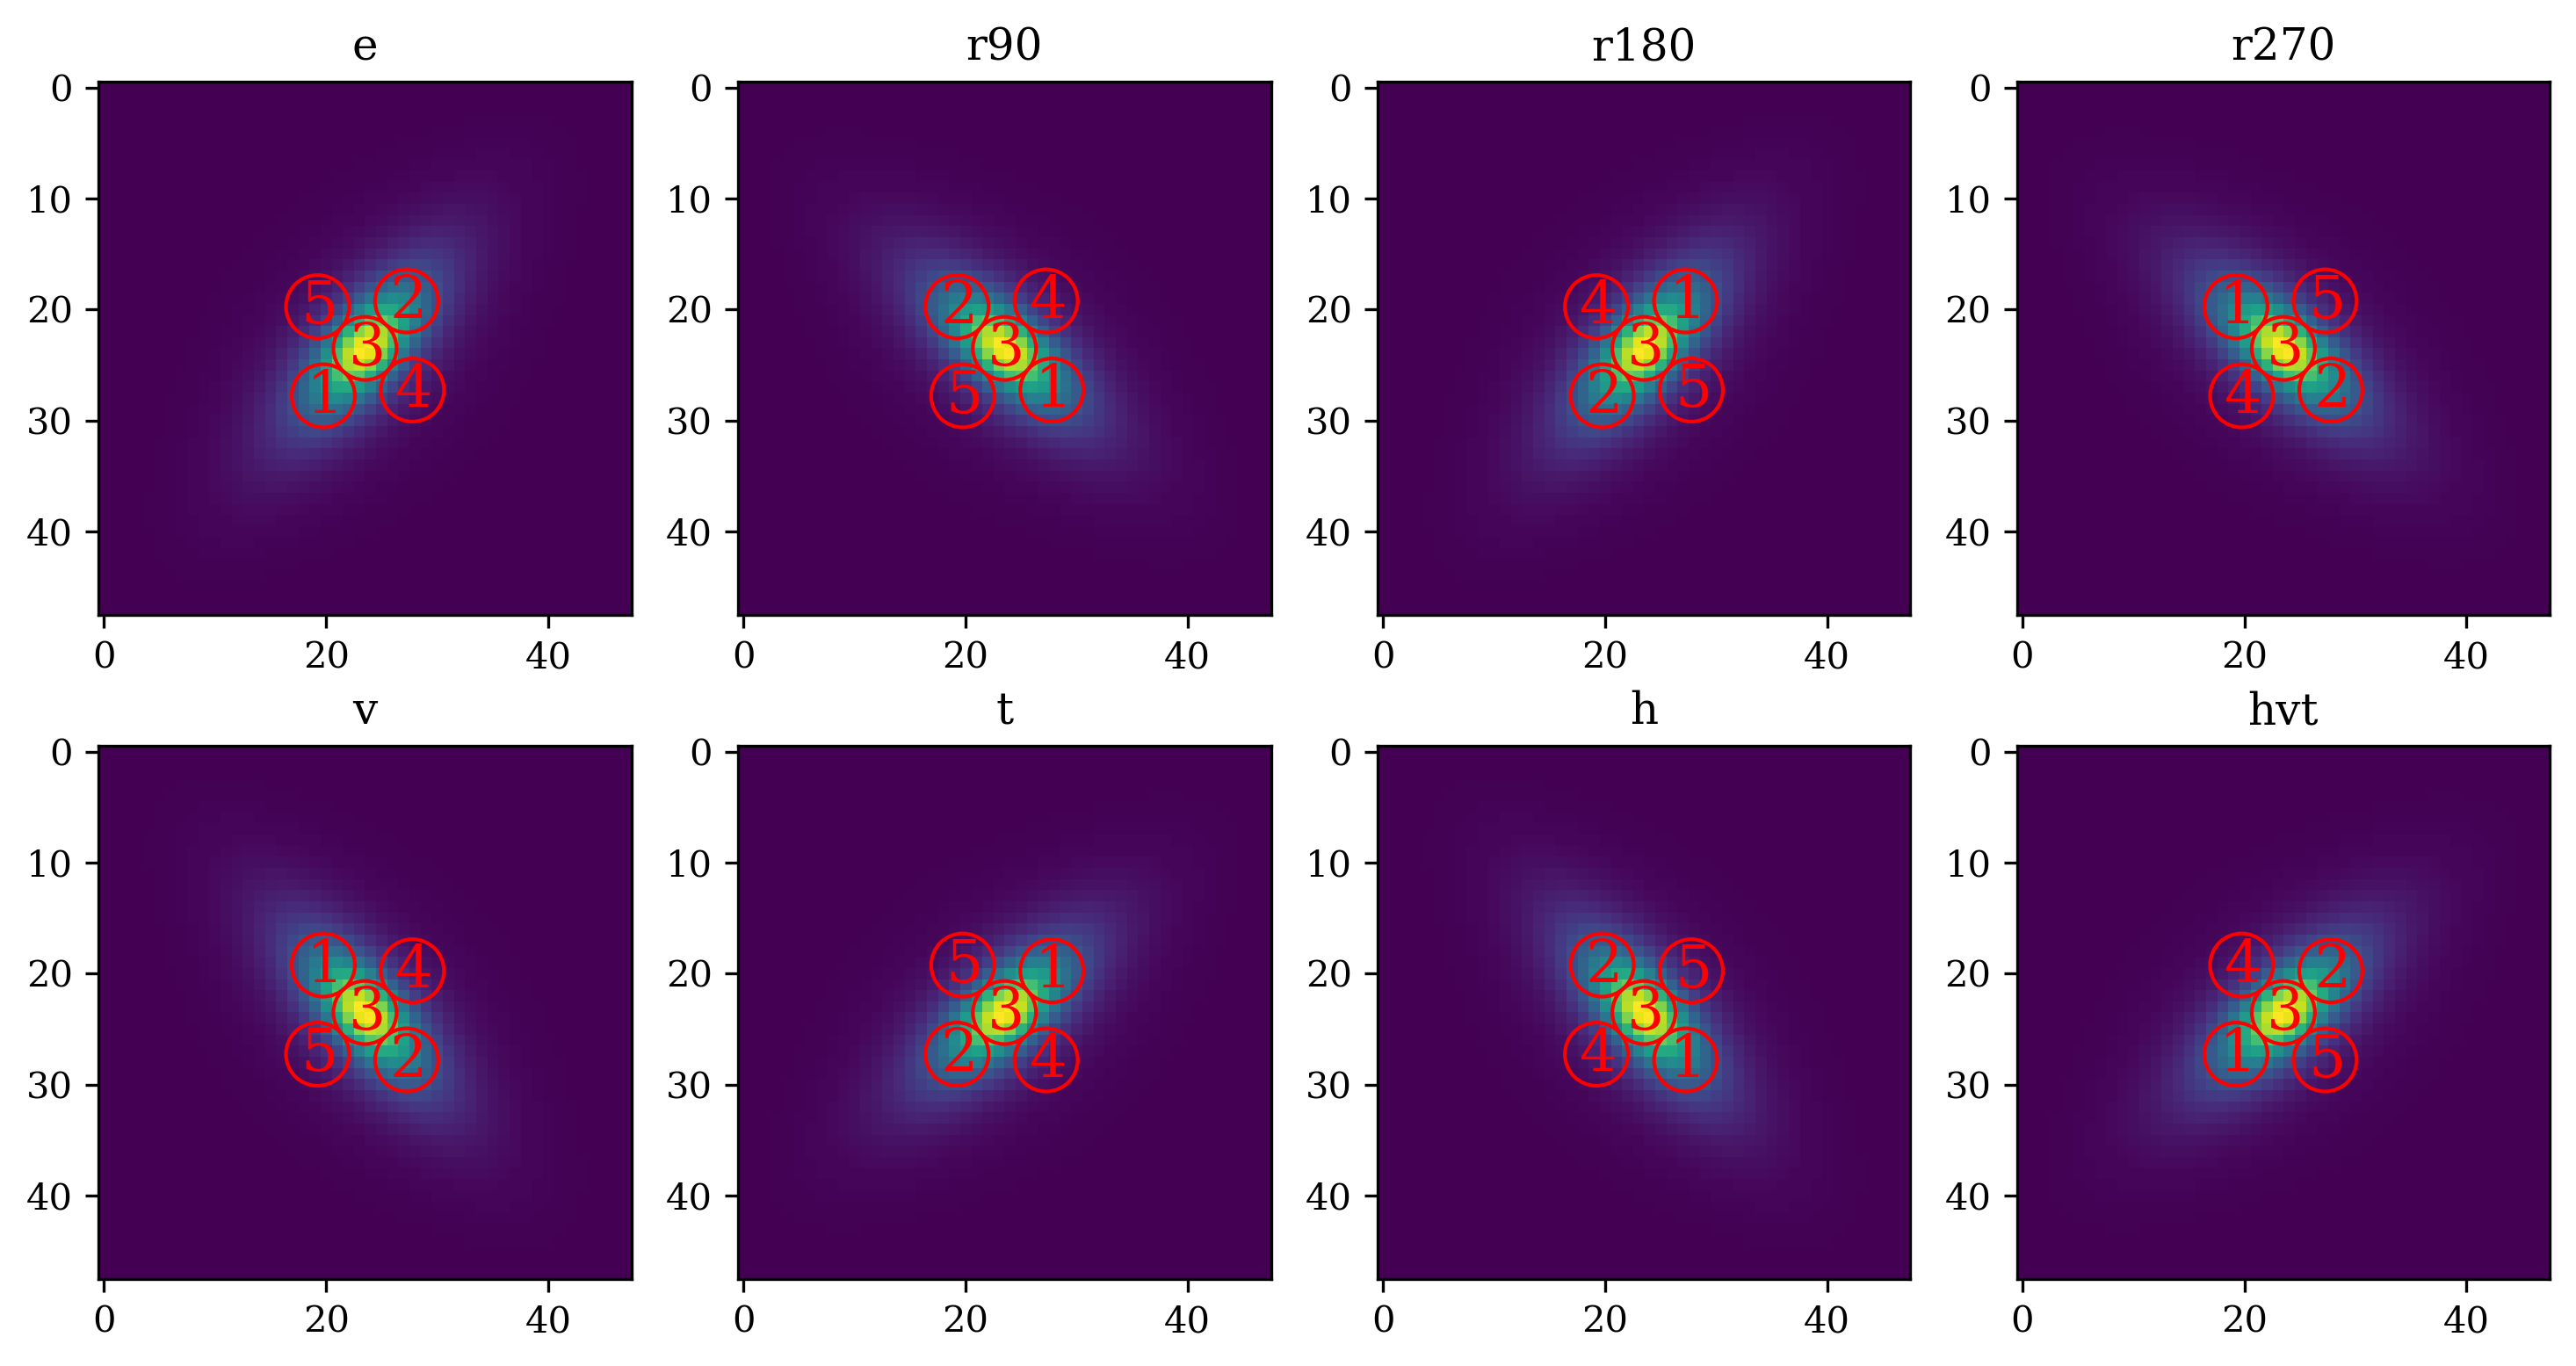

In [12]:
axs = plt.figure(figsize=(12, 6)).subplots(2, 4)
pixscale = 0.2637
for i, ax in enumerate(axs.ravel()):
    g = d4_set[i]
    ax.imshow(g['img'][0])
    ax.set_title(d4_trans[i])
    
    for j in range(5):
        x, y = g['fib_pos'][j]
        x = x/pixscale + 23.5
        y = y/pixscale + 23.5
        offsetpos = (x,y)
        fiber = patches.Circle(offsetpos, 0.75/pixscale, color='red', fill=False)
        ax.add_patch(fiber)
        ax.text(x-1.5, y+1.5, f'{j+1}', fontsize=16, color='red')

plt.savefig(join(fig_dir, stem, f'd4_trans.png'), dpi=300)
plt.show()


### Regenerate datavectors for D4 verification
Generate fresh FITS datavectors from transformed parameters and compare against array-level D4 transforms.


In [17]:
from pathlib import Path
import subprocess

def _denorm_par_dict(fid_norm):
    vals = denormalize(
        np.asarray(fid_norm, dtype=np.float64),
        config.par_ranges,
        config.train['feature_names'],
    )
    return dict(zip(config.train['feature_names'], vals))


def _norm_par_dict(pars):
    vals = []
    for name in config.train['feature_names']:
        lo, hi = config.par_ranges[name]
        x = float(pars[name])
        vals.append((2 * x - (hi + lo)) / (hi - lo))
    return np.asarray(vals, dtype=np.float32)


def _load_generated_arrays(fits_path, nspec=5):
    with fits.open(fits_path) as hdu:
        img = torch.from_numpy(hdu[nspec + 1].data.astype(np.float32))
        spec = np.zeros((nspec, 64), dtype=np.float32)
        fib_pos = np.zeros((nspec, 2), dtype=np.float32)
        for k in range(nspec):
            arr = hdu[k + 1].data.astype(np.float32)
            spec[k, :arr.shape[0]] = arr
            fib_pos[k, 0] = hdu[k + 1].header['FIBERDX']
            fib_pos[k, 1] = hdu[k + 1].header['FIBERDY']
    return img, torch.from_numpy(spec), torch.from_numpy(fib_pos)


def _run_generate_fits(pars, dataset_name='tmp_d4_verify', part_id=1, sample_id=900000, fiber_perm=None):
    script = Path(arch_dir).parent / 'data_generate' / 'generate_fits.py'
    out_dir = Path('/ocean/projects/phy250048p/shared/fits') / dataset_name / f'part_{part_id}'
    out_dir.mkdir(parents=True, exist_ok=True)

    if fiber_perm is None:
        fiber_perm = [0, 1, 2, 3, 4]
    fiber_perm_arg = ','.join(str(int(i)) for i in fiber_perm)

    cmd = [
        sys.executable,
        str(script),
        '-n', str(part_id),
        '-d', dataset_name,
        '-ID', str(sample_id),
        '-g1', str(float(pars['g1'])),
        '-g2', str(float(pars['g2'])),
        '-theta_int', str(float(pars['theta_int'])),
        '-sini', str(float(pars['sini'])),
        '-v0', str(float(pars['v0'])),
        '-vcirc', str(float(pars['vcirc'])),
        '-rscale', str(float(pars['rscale'])),
        '-hlr', str(float(pars['hlr'])),
        '--fiber_perm', fiber_perm_arg,
    ]
    subprocess.run(cmd, check=True, cwd=script.parent)

    fits_path = out_dir / f'gal_{sample_id}.fits'
    if not fits_path.exists():
        raise FileNotFoundError(f'Expected generated FITS not found: {fits_path}')
    return fits_path


def _plot_d4_regen_diffs(d4_set, regenerated, d4_trans, dataset_name='tmp_d4_verify', tag='default', frac_eps=1e-8, pars=None):
    from mpl_toolkits.axes_grid1 import make_axes_locatable

    plot_dir = Path('/ocean/projects/phy250048p/shared/plots') / dataset_name
    plot_dir.mkdir(parents=True, exist_ok=True)

    img_frac_list = []
    for i in range(len(d4_trans)):
        arr_img = d4_set[i]['img'][0].float().cpu()
        gen_img = regenerated[i]['img'].float().cpu()
        img_frac_list.append(((arr_img - gen_img) / torch.clamp(torch.abs(arr_img), min=frac_eps)).numpy())

    img_vmax = max(float(np.max(np.abs(v))) for v in img_frac_list)
    if img_vmax == 0:
        img_vmax = 1e-8

    fig_img, axs_img = plt.subplots(2, 4, figsize=(14, 7), constrained_layout=True)
    for i, ax in enumerate(axs_img.ravel()):
        im = ax.imshow(img_frac_list[i], cmap='RdBu_r', vmin=-img_vmax, vmax=img_vmax)
        ax.set_title(d4_trans[i])
        ax.set_xticks([])
        ax.set_yticks([])
    fig_img.colorbar(im, ax=axs_img.ravel().tolist(), shrink=0.85, label='signed fractional diff')
    img_path = plot_dir / f'd4_img_fracdiff_2x4_{tag}.png'
    fig_img.savefig(img_path, dpi=300)
    plt.close(fig_img)

    spec_frac_list = []
    for i in range(len(d4_trans)):
        arr_spec = d4_set[i]['spec'][0].float().cpu()
        gen_spec = regenerated[i]['spec'].float().cpu()
        spec_frac_list.append(((arr_spec - gen_spec) / torch.clamp(torch.abs(arr_spec), min=frac_eps)).numpy())

    spec_vmax = max(float(np.max(np.abs(v))) for v in spec_frac_list)
    if spec_vmax == 0:
        spec_vmax = 1e-8

    fig_spec, axs_spec = plt.subplots(2, 4, figsize=(16, 10))
    for i, ax in enumerate(axs_spec.ravel()):
        frac = spec_frac_list[i]
        x = np.arange(frac.shape[1])

        divider = make_axes_locatable(ax)
        sub_axes = [ax]
        for _ in range(4):
            sub_axes.append(divider.append_axes('top', size='100%', pad=0, sharex=ax))

        sub_axes = sorted(sub_axes, key=lambda a: a.get_position().y0)

        for k, sax in enumerate(sub_axes):
            sax.plot(x, frac[k], lw=0.9, color=f'C{k}')
            sax.axhline(0, color='black', lw=0.6, linestyle='--')
            sax.axvline(30, color='black', lw=0.6, linestyle='--')
            sax.set_ylim(-spec_vmax, spec_vmax)
            sax.grid(alpha=0.2)
            sax.text(0.01, 0.82, f'f{k+1}', transform=sax.transAxes, fontsize=7)
            if k > 0:
                sax.tick_params(labelbottom=False)
            else:
                sax.set_xlabel('wavelength index')
            sax.set_xticks([])

        sub_axes[-1].set_title(d4_trans[i])
    if pars is not None:
        param_str = ', '.join(f'{k}={v}' for k, v in pars.items())
        plt.suptitle(f'Parameters: {param_str}')
    spec_path = plot_dir / f'd4_spec_fracdiff_2x4_{tag}.png'
    fig_spec.savefig(spec_path, dpi=300)
    plt.close(fig_spec)

    return img_path, spec_path


def make_temp_sample_from_params(pars, dataset_name='tmp_d4_verify', part_id=1, sample_id=980000):
    fits_path = _run_generate_fits(pars, dataset_name=dataset_name, part_id=part_id, sample_id=sample_id)
    img, spec, fib_pos = _load_generated_arrays(fits_path)
    fits_path.unlink()

    fid_norm = _norm_par_dict(pars)
    gal = {
        'img': img.unsqueeze(0),
        'spec': spec.unsqueeze(0),
        'fib_pos': fib_pos,
        'fid_pars': torch.from_numpy(fid_norm),
        'id': np.uint64(sample_id),
    }
    return gal


def regenerate_d4_datavectors(d4_set, d4_trans=None, dataset_name='tmp_d4_verify', part_id=1, start_id=900000):
    if d4_trans is None:
        d4_trans = ['e'] * len(d4_set)

    regenerated = []
    for i, g in enumerate(d4_set):
        pars = _denorm_par_dict(g['fid_pars'])
        sample_id = start_id + i
        fiber_perm = D4_SPEC_PERM_GENERATE.get(d4_trans[i], [0, 1, 2, 3, 4])
        fits_path = _run_generate_fits(
            pars,
            dataset_name=dataset_name,
            part_id=part_id,
            sample_id=sample_id,
            fiber_perm=fiber_perm,
        )
        img, spec, fib_pos = _load_generated_arrays(fits_path)
        fits_path.unlink()
        regenerated.append({'img': img, 'spec': spec, 'fib_pos': fib_pos, 'id': sample_id})

    return regenerated


def d4_compare_from_params(pars, dataset_name='tmp_d4_verify', part_id=1, sample_id=980000):
    gal = make_temp_sample_from_params(pars, dataset_name=dataset_name, part_id=part_id, sample_id=sample_id)
    d4_set, d4_trans, _, _ = build_d4_datavector_set(gal)
    regen = regenerate_d4_datavectors(
        d4_set,
        d4_trans=d4_trans,
        dataset_name=dataset_name,
        part_id=part_id,
        start_id=sample_id + 100,
    )
    summary, fiber_l2 = summarize_d4_regen_diffs(d4_set, regen, d4_trans)
    img_plot, spec_plot = _plot_d4_regen_diffs(
        d4_set, regen, d4_trans, dataset_name=dataset_name, tag=f'params_{sample_id}', pars=pars
    )
    return gal, d4_set, regen, summary, fiber_l2, img_plot, spec_plot


In [14]:
def summarize_d4_regen_diffs(d4_set, regenerated, d4_trans, frac_eps=1e-8):
    rows = []
    for i, t in enumerate(d4_trans):
        arr_img = d4_set[i]['img'][0].float().cpu()
        arr_spec = d4_set[i]['spec'][0].float().cpu()
        arr_fp = d4_set[i]['fib_pos'].float().cpu()

        gen_img = regenerated[i]['img'].float().cpu()
        gen_spec = regenerated[i]['spec'].float().cpu()
        gen_fp = regenerated[i]['fib_pos'].float().cpu()

        dimg = arr_img - gen_img
        dspec = arr_spec - gen_spec
        dfp = arr_fp - gen_fp

        img_frac = torch.abs(dimg) / torch.clamp(torch.abs(arr_img), min=frac_eps)
        spec_frac = torch.abs(dspec) / torch.clamp(torch.abs(arr_spec), min=frac_eps)

        rows.append({
            'transform': t,
            'img_max_frac_err': float(torch.max(img_frac)),
            'img_l2': float(torch.linalg.norm(dimg)),
            'spec_max_frac_err': float(torch.max(spec_frac)),
            'spec_l2': float(torch.linalg.norm(dspec)),
            'fib_max_abs': float(torch.max(torch.abs(dfp))),
            'fib_l2': float(torch.linalg.norm(dfp)),
        })

    summary = pd.DataFrame(rows)

    fiber_spec_l2 = []
    for i in range(len(d4_trans)):
        arr_spec = d4_set[i]['spec'][0].float().cpu()
        gen_spec = regenerated[i]['spec'].float().cpu()
        fiber_spec_l2.append(torch.linalg.norm(arr_spec - gen_spec, dim=1).numpy())
    fiber_spec_l2 = pd.DataFrame(
        np.stack(fiber_spec_l2, axis=0),
        index=d4_trans,
        columns=[f'fiber_{k}_l2' for k in range(5)],
    )

    return summary, fiber_spec_l2


In [18]:
regen = regenerate_d4_datavectors(d4_set, d4_trans=d4_trans, dataset_name='tmp_d4_verify', part_id=1)
regen_summary, regen_fiber_l2 = summarize_d4_regen_diffs(d4_set, regen, d4_trans)
img_plot, spec_plot = _plot_d4_regen_diffs(d4_set, regen, d4_trans, dataset_name='tmp_d4_verify', tag='dataset_example_1')
print(f'image diff plot: {img_plot}')
print(f'spectra diff plot: {spec_plot}')
regen_summary


Can not import MPI, use single process
FiberLikelihood: Generating data vector from fid pars...
FiberLikelihood: Caching the (fiducial) data vector...
Dataset tmp_d4_verify #900000 generated
Can not import MPI, use single process
FiberLikelihood: Generating data vector from fid pars...
FiberLikelihood: Caching the (fiducial) data vector...
Dataset tmp_d4_verify #900001 generated
Can not import MPI, use single process
FiberLikelihood: Generating data vector from fid pars...
FiberLikelihood: Caching the (fiducial) data vector...
Dataset tmp_d4_verify #900002 generated
Can not import MPI, use single process
FiberLikelihood: Generating data vector from fid pars...
FiberLikelihood: Caching the (fiducial) data vector...
Dataset tmp_d4_verify #900003 generated
Can not import MPI, use single process
FiberLikelihood: Generating data vector from fid pars...
FiberLikelihood: Caching the (fiducial) data vector...
Dataset tmp_d4_verify #900004 generated
Can not import MPI, use single process
FiberL

,transform,img_max_frac_err,img_l2,spec_max_frac_err,spec_l2,fib_max_abs,fib_l2
0,e,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.0
1,r90,0.000004,0.000002,5.753209e-07,0.000034,0.000000,0.0
2,r180,0.000002,0.000002,7.259939e-07,0.000026,0.000000,0.0
3,r270,0.000004,0.000002,8.104483e-07,0.000053,0.000000,0.0
4,v,0.000004,0.000002,8.104483e-07,0.000053,0.000000,0.0
5,t,0.000003,0.000002,7.259939e-07,0.000026,2.253072,6.0
6,h,0.000004,0.000002,5.753209e-07,0.000034,0.000000,0.0
7,hvt,0.000004,0.000002,0.000000e+00,0.000000,2.253072,6.0


In [15]:
regen_fiber_l2

,fiber_0_l2,fiber_1_l2,fiber_2_l2,fiber_3_l2,fiber_4_l2
e,0.000000,0.000000,0.0,0.000000,0.000000
r90,0.000055,0.000054,0.0,0.000003,0.000003
r180,0.000052,0.000051,0.0,0.000048,0.000045
r270,0.000002,0.000003,0.0,0.000045,0.000043
v,0.000002,0.000003,0.0,0.000043,0.000045
t,0.000052,0.000051,0.0,0.000045,0.000048
h,0.000055,0.000054,0.0,0.000003,0.000003
hvt,0.000000,0.000000,0.0,0.000000,0.000000


### Arbitrary-parameter synthetic D4 check
Generate one temporary sample from explicit physical parameters, apply D4 array transforms, regenerate, and compare.


In [32]:
temp_pars = {
    'g1': 0.05,
    'g2': 0.05,
    'theta_int': np.pi/4,
    'sini': 0.7,
    'v0': 0.0,
    'vcirc': 100.0,
    'rscale': 2.0,
    'hlr': 2.0,
}
_, temp_d4_set, temp_regen, temp_summary, temp_fiber_l2, temp_img_plot, temp_spec_plot = d4_compare_from_params(
    temp_pars, dataset_name='tmp_d4_verify', part_id=1, sample_id=0
)
print(f'image diff plot: {temp_img_plot}')
print(f'spectra diff plot: {temp_spec_plot}')
temp_summary


Can not import MPI, use single process
FiberLikelihood: Generating data vector from fid pars...
FiberLikelihood: Caching the (fiducial) data vector...
Dataset tmp_d4_verify #0 generated
Can not import MPI, use single process
FiberLikelihood: Generating data vector from fid pars...
FiberLikelihood: Caching the (fiducial) data vector...
Dataset tmp_d4_verify #100 generated
Can not import MPI, use single process
FiberLikelihood: Generating data vector from fid pars...
FiberLikelihood: Caching the (fiducial) data vector...
Dataset tmp_d4_verify #101 generated
Can not import MPI, use single process
FiberLikelihood: Generating data vector from fid pars...
FiberLikelihood: Caching the (fiducial) data vector...
Dataset tmp_d4_verify #102 generated
Can not import MPI, use single process
FiberLikelihood: Generating data vector from fid pars...
FiberLikelihood: Caching the (fiducial) data vector...
Dataset tmp_d4_verify #103 generated
Can not import MPI, use single process
FiberLikelihood: Genera

,transform,img_max_frac_err,img_l2,spec_max_frac_err,spec_l2,fib_max_abs,fib_l2
0,e,6.513279e-07,0.000004,1.175173e-07,0.000001,0.000000e+00,0.000000e+00
1,r90,3.023192e-06,0.000004,7.825303e-07,0.000048,0.000000e+00,0.000000e+00
2,r180,7.649443e-07,0.000004,1.173795e-06,0.000068,0.000000e+00,0.000000e+00
3,r270,2.821646e-06,0.000007,7.156153e-07,0.000033,1.788139e-07,4.298152e-07
4,v,2.227003e-06,0.000004,6.643326e-07,0.000034,0.000000e+00,0.000000e+00
5,t,1.061886e-06,0.000004,1.173795e-06,0.000068,2.355347e+00,6.000000e+00
6,h,1.903378e-06,0.000008,7.825303e-07,0.000049,1.788139e-07,4.298152e-07
7,hvt,1.543174e-06,0.000007,1.175173e-07,0.000003,2.355347e+00,6.000000e+00


In [29]:
thetas = np.arange(-np.pi, np.pi, np.pi/4)
gals = []
for theta in thetas:
    temp_pars = {
        'g1': 0.0,
        'g2': 0.0,
        'theta_int': theta,
        'sini': 0.5,
        'v0': 0.0,
        'vcirc': 100.0,
        'rscale': 2.0,
        'hlr': 2.0,
    }
    gal = make_temp_sample_from_params(temp_pars, dataset_name='tmp_d4_verify', part_id=1, sample_id=0)
    gals.append(gal)

Can not import MPI, use single process
FiberLikelihood: Generating data vector from fid pars...
FiberLikelihood: Caching the (fiducial) data vector...
Dataset tmp_d4_verify #0 generated
Can not import MPI, use single process
FiberLikelihood: Generating data vector from fid pars...
FiberLikelihood: Caching the (fiducial) data vector...
Dataset tmp_d4_verify #0 generated
Can not import MPI, use single process
FiberLikelihood: Generating data vector from fid pars...
FiberLikelihood: Caching the (fiducial) data vector...
Dataset tmp_d4_verify #0 generated
Can not import MPI, use single process
FiberLikelihood: Generating data vector from fid pars...
FiberLikelihood: Caching the (fiducial) data vector...
Dataset tmp_d4_verify #0 generated
Can not import MPI, use single process
FiberLikelihood: Generating data vector from fid pars...
FiberLikelihood: Caching the (fiducial) data vector...
Dataset tmp_d4_verify #0 generated
Can not import MPI, use single process
FiberLikelihood: Generating dat

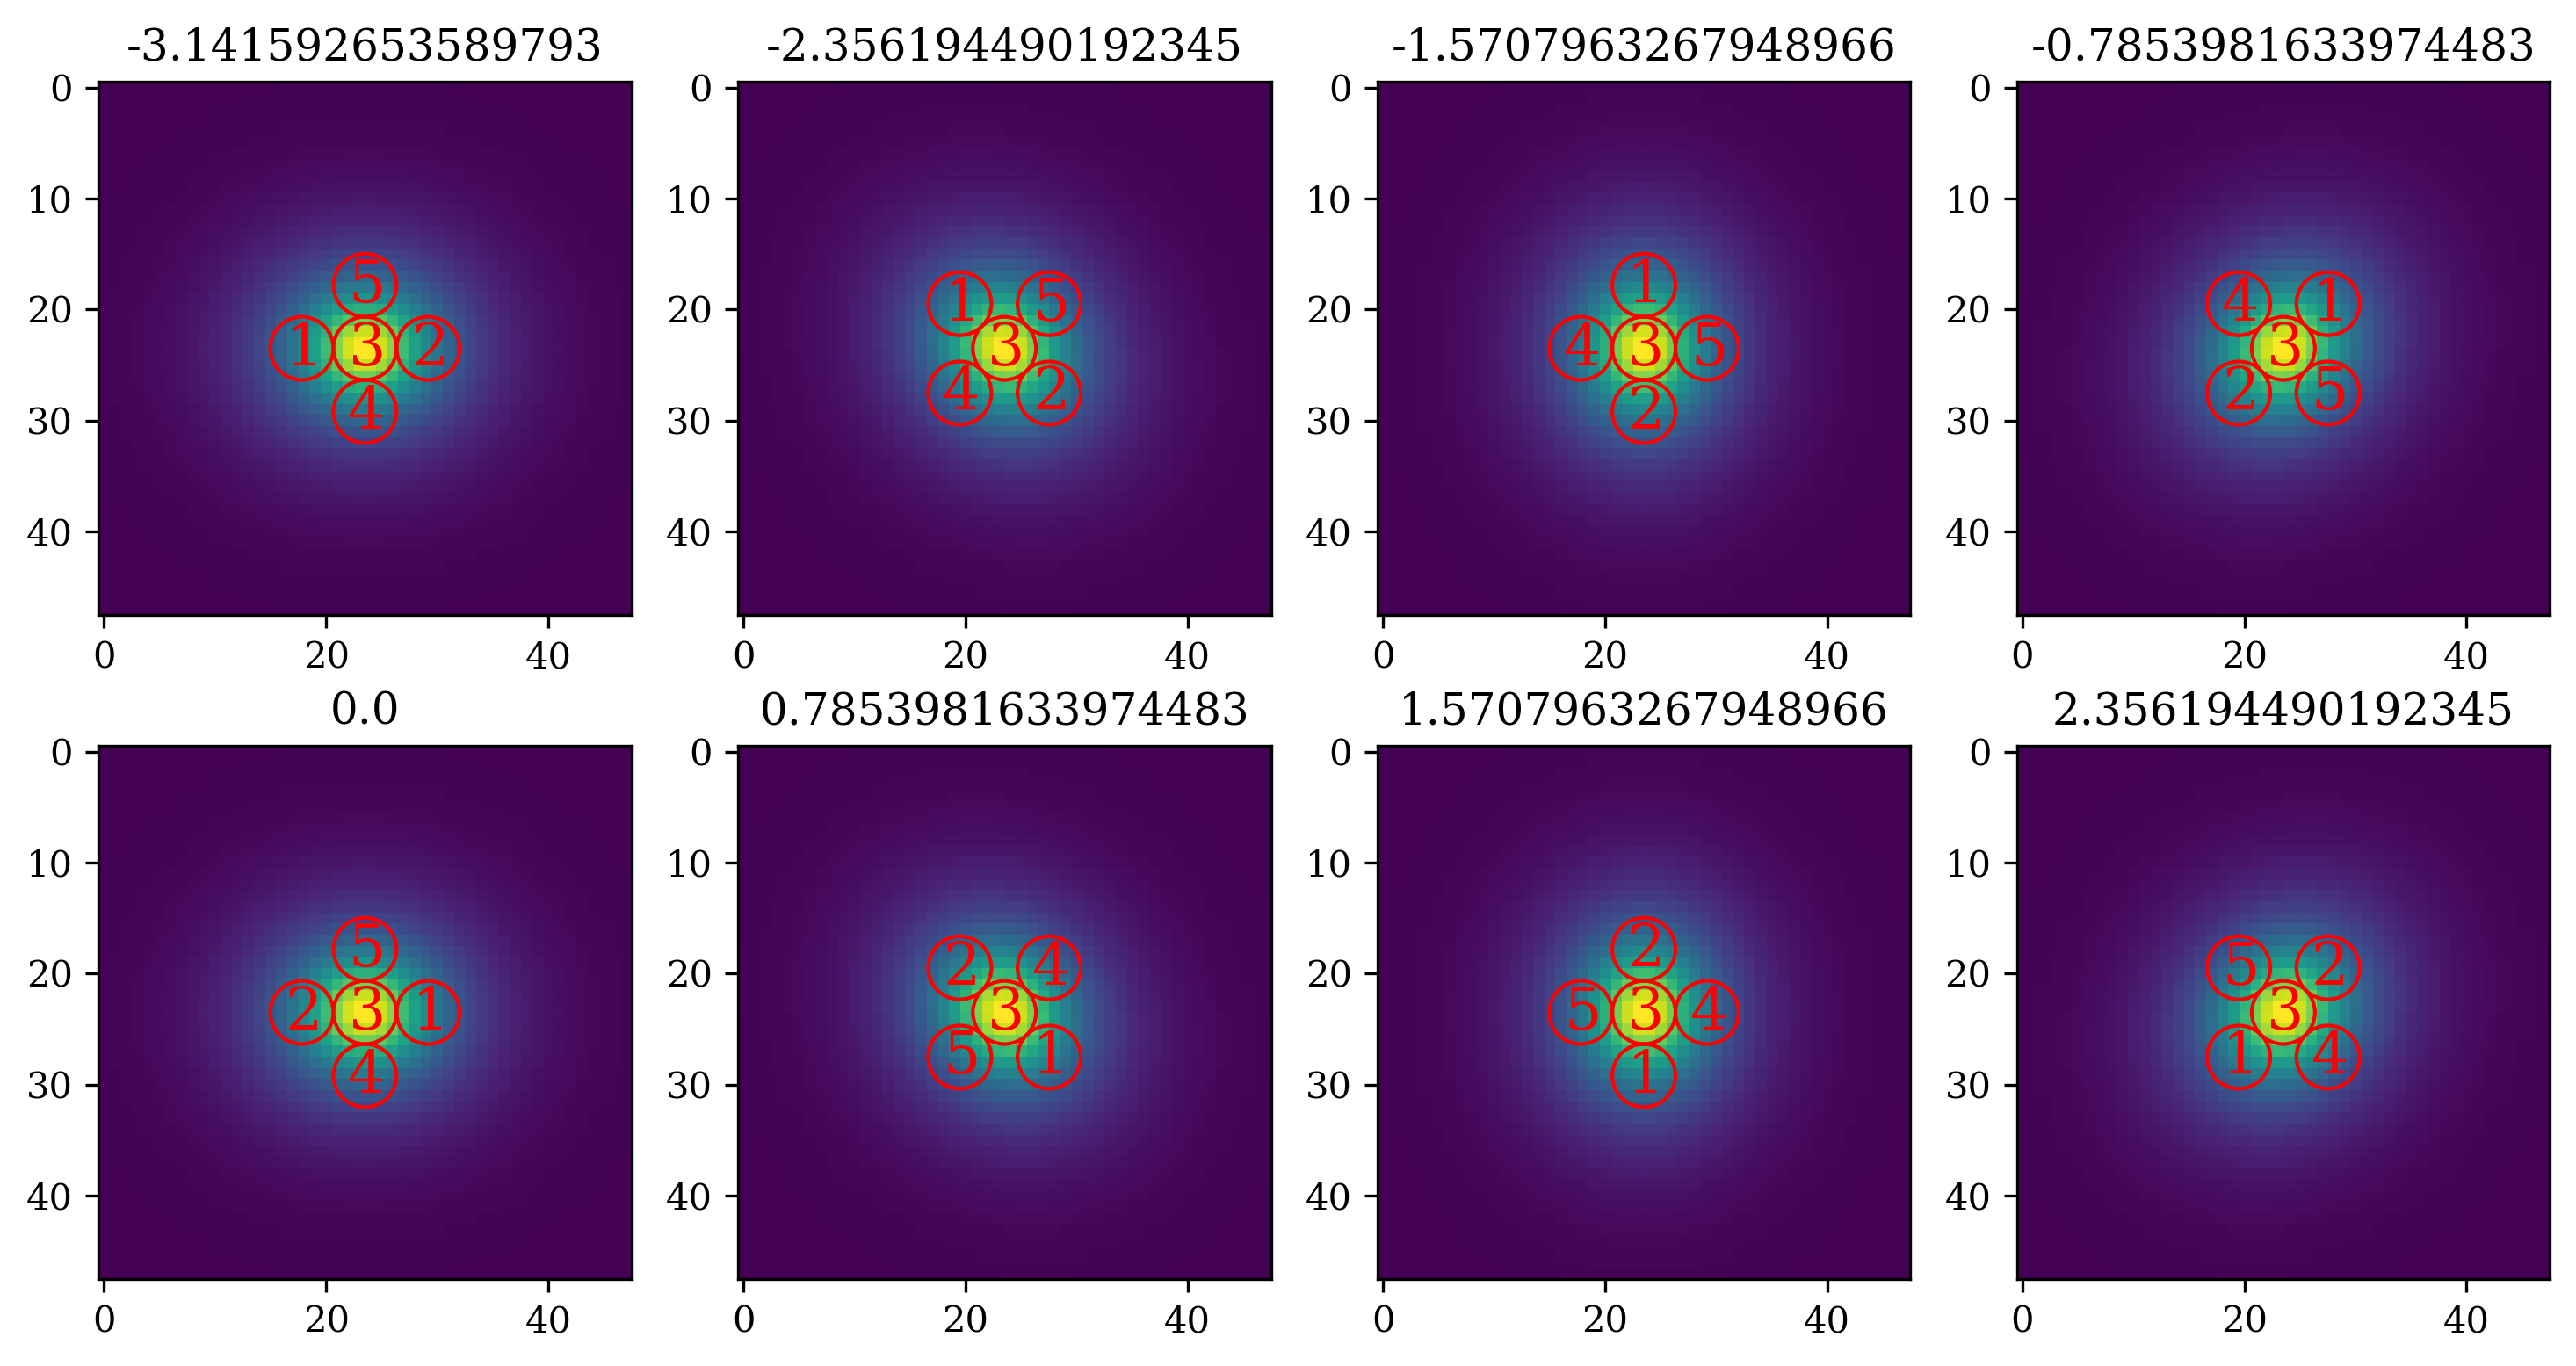

In [31]:
axs = plt.figure(figsize=(12, 6)).subplots(2, 4)
pixscale = 0.2637
for i, ax in enumerate(axs.ravel()):
    g = gals[i]
    ax.imshow(g['img'][0])
    ax.set_title(thetas[i])
    
    for j in range(5):
        x, y = g['fib_pos'][j]
        x = x/pixscale + 23.5
        y = y/pixscale + 23.5
        offsetpos = (x,y)
        fiber = patches.Circle(offsetpos, 0.75/pixscale, color='red', fill=False)
        ax.add_patch(fiber)
        ax.text(x-1.5, y+1.5, f'{j+1}', fontsize=16, color='red')

plt.savefig(join(fig_dir, stem, f'rotation_check.png'), dpi=300)
plt.show()

### Analyze average D4 diffs

In [13]:
def d4_diff(gal_id, use_vcirc=False):
    gal = test_ds[gal_id]
    d4_set, d4_trans, _, _ = build_d4_datavector_set(gal)
    # regen = regenerate_d4_datavectors(d4_set, d4_trans, dataset_name='tmp_d4_verify', part_id=1, start_id=900000)

    model.eval()
    samples = []
    log_probs = []
    snr = torch.rand((1,), device=device)*995 + 5
    with torch.no_grad():
        for i, g in enumerate(d4_set):
            img = apply_noise(g['img'].float().unsqueeze(0).to(device), snr, device=device)
            spec = apply_noise(g['spec'].float().unsqueeze(0).to(device), snr, device=device)
            vcirc = torch.Tensor([fid_pars_phys.iloc[gal_id]['vcirc']]).to(device) if use_vcirc else None
            fp = apply_noise(g['fib_pos'].float().unsqueeze(0).to(device), snr, device=device)
            samp, lp = model.sample(img, spec, num_samples=10000, fp=fp, vcirc_mu=vcirc, return_log_prob=True)
            samples.append(samp.detach().cpu().numpy())
            log_probs.append(lp.detach().cpu().numpy())
    samples = np.vstack(samples)
    log_probs = np.vstack(log_probs)
    truth = np.vstack([g['fid_pars'] for g in d4_set])
    map_idx = np.argmax(log_probs, axis=1)
    maps = np.vstack([samples[i, map_idx[i]] for i in range(len(map_idx))])
    diff = maps - truth
    return diff, truth, maps


In [14]:
diffs = []
truths = []
preds = []
nsamps = 1000
model.mode = 1
for i in range(2000, 2000+nsamps):
    diff, truth, maps = d4_diff(i, use_vcirc=False)
    diffs.append(diff)
    truths.append(truth)
    preds.append(maps)


In [15]:
diffs = np.stack(diffs, axis=0)
truths = np.stack(truths, axis=0)
preds = np.stack(preds, axis=0)

In [36]:
g_bias = np.mean(diffs[:, :, :2], axis=0) * 0.1
g_std = np.std(diffs[:, :, :2], axis=0) * 0.1 / np.sqrt(nsamps)

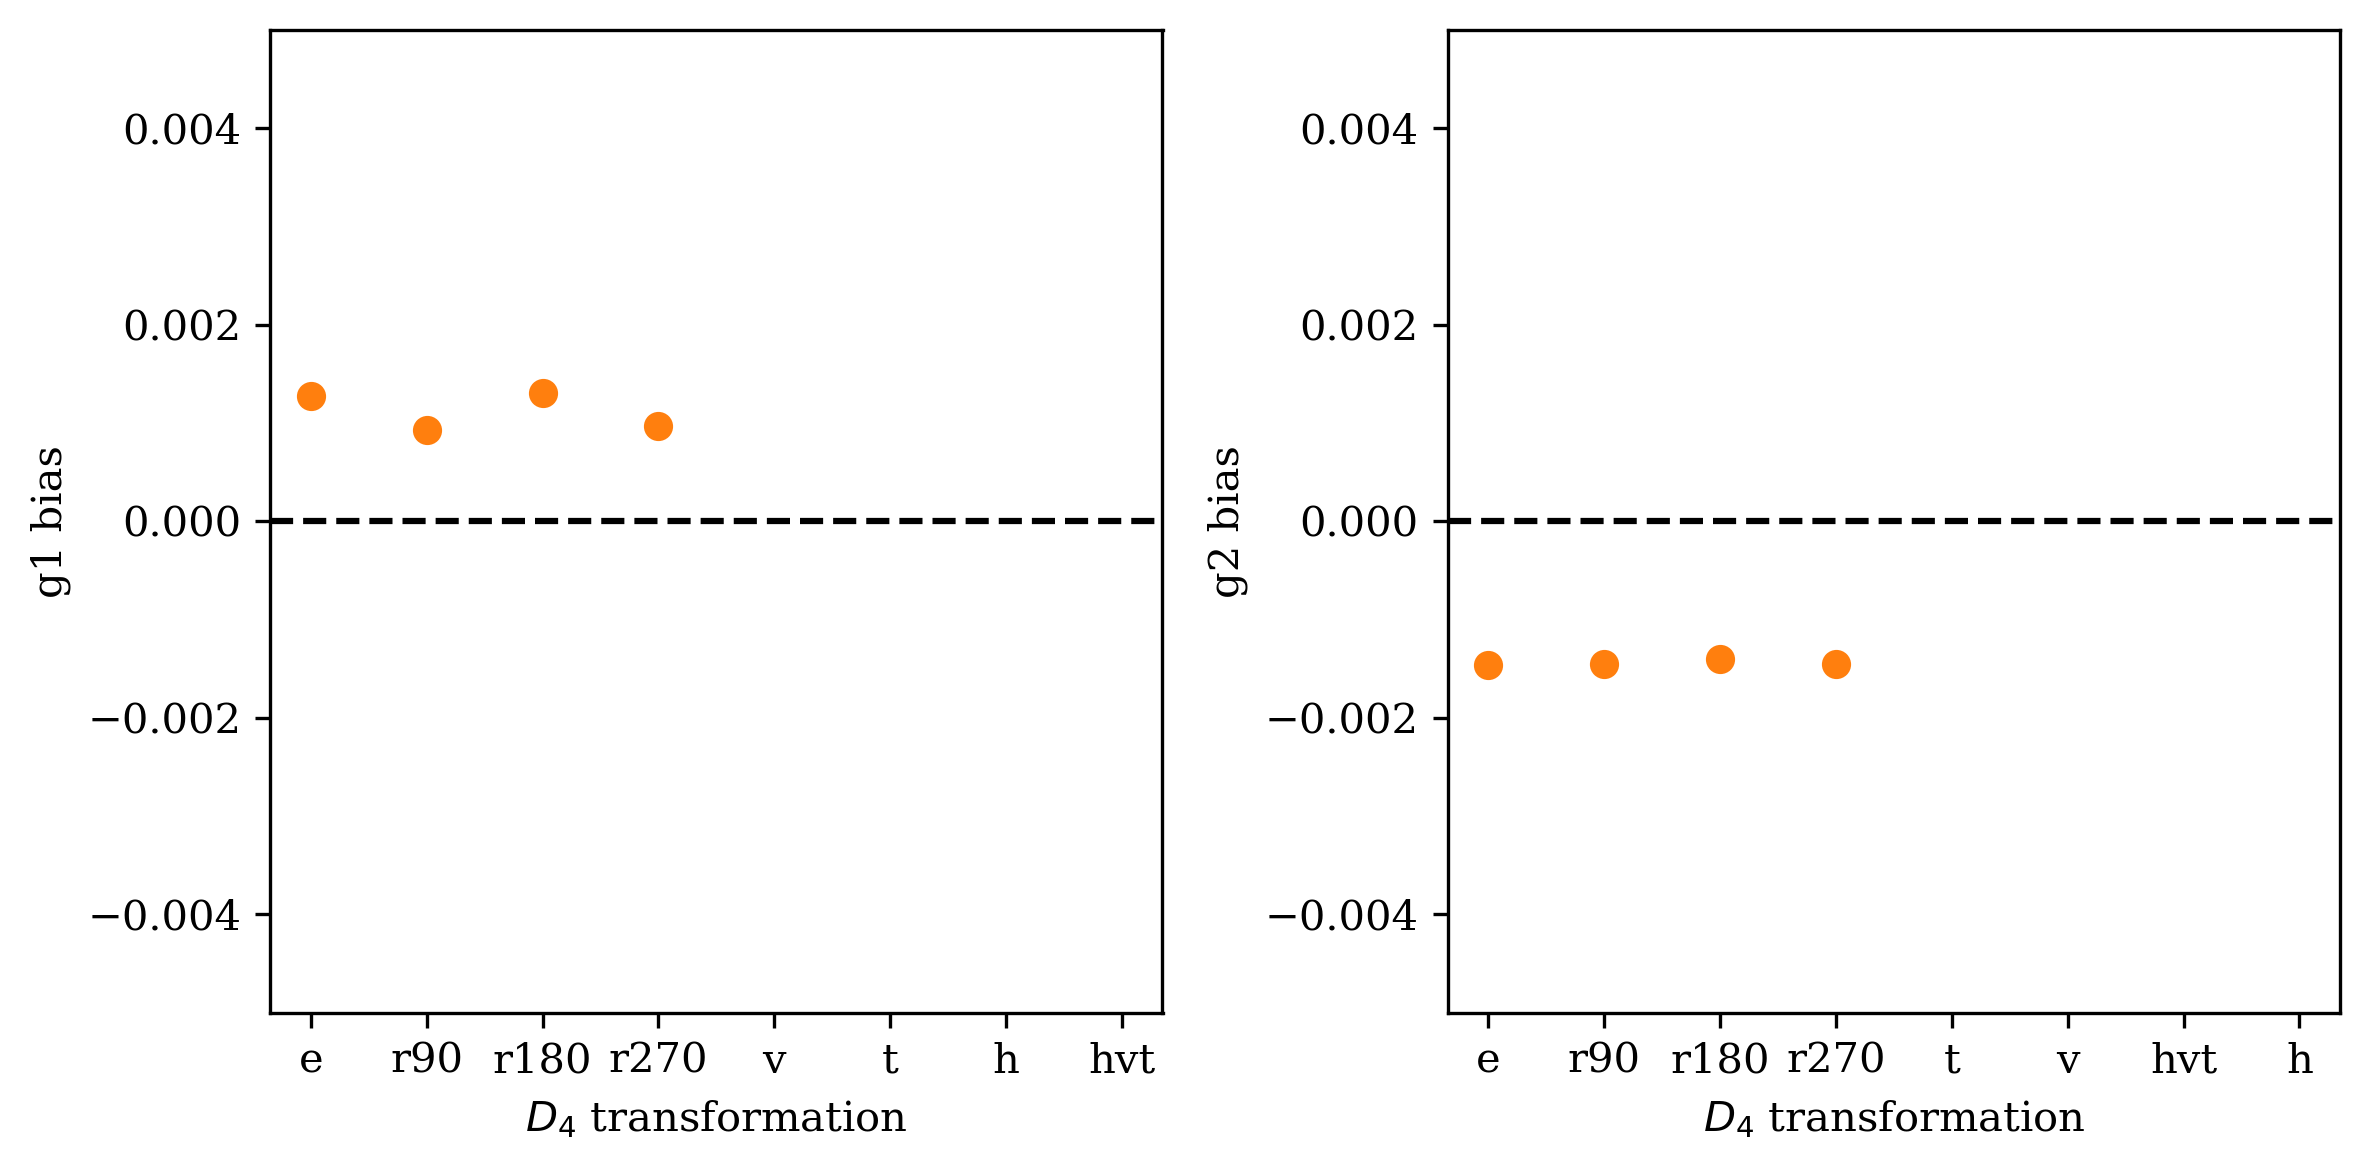

In [39]:
x = np.arange(0, 8)
axs = plt.figure(figsize=(8, 4)).subplots(1, 2)
for i, ax in enumerate(axs.ravel()):
    order = [0, 1, 2, 3, 4, 5, 6, 7] if i == 0 else [0, 1, 2, 3, 5, 4, 7, 6]
    ticklabel = [d4_trans[order[i]] for i in range(8)]
    ax.errorbar(x, g_bias[order, i], g_std[order, i], linestyle='', elinewidth=1, marker='o', color='C1')
    ax.axhline(0, linestyle='--', color='black')
    ax.set_xticks(x, labels=ticklabel)
    ax.set_ylim(-0.005, 0.005)
    ax.set_xlabel(r'$D_4$ transformation')
    ax.set_ylabel(f'g{i+1} bias')

plt.tight_layout()
plt.savefig(join(fig_dir, stem, f'D4_summary_g_{nsamps}.png'), dpi=300)
plt.show()


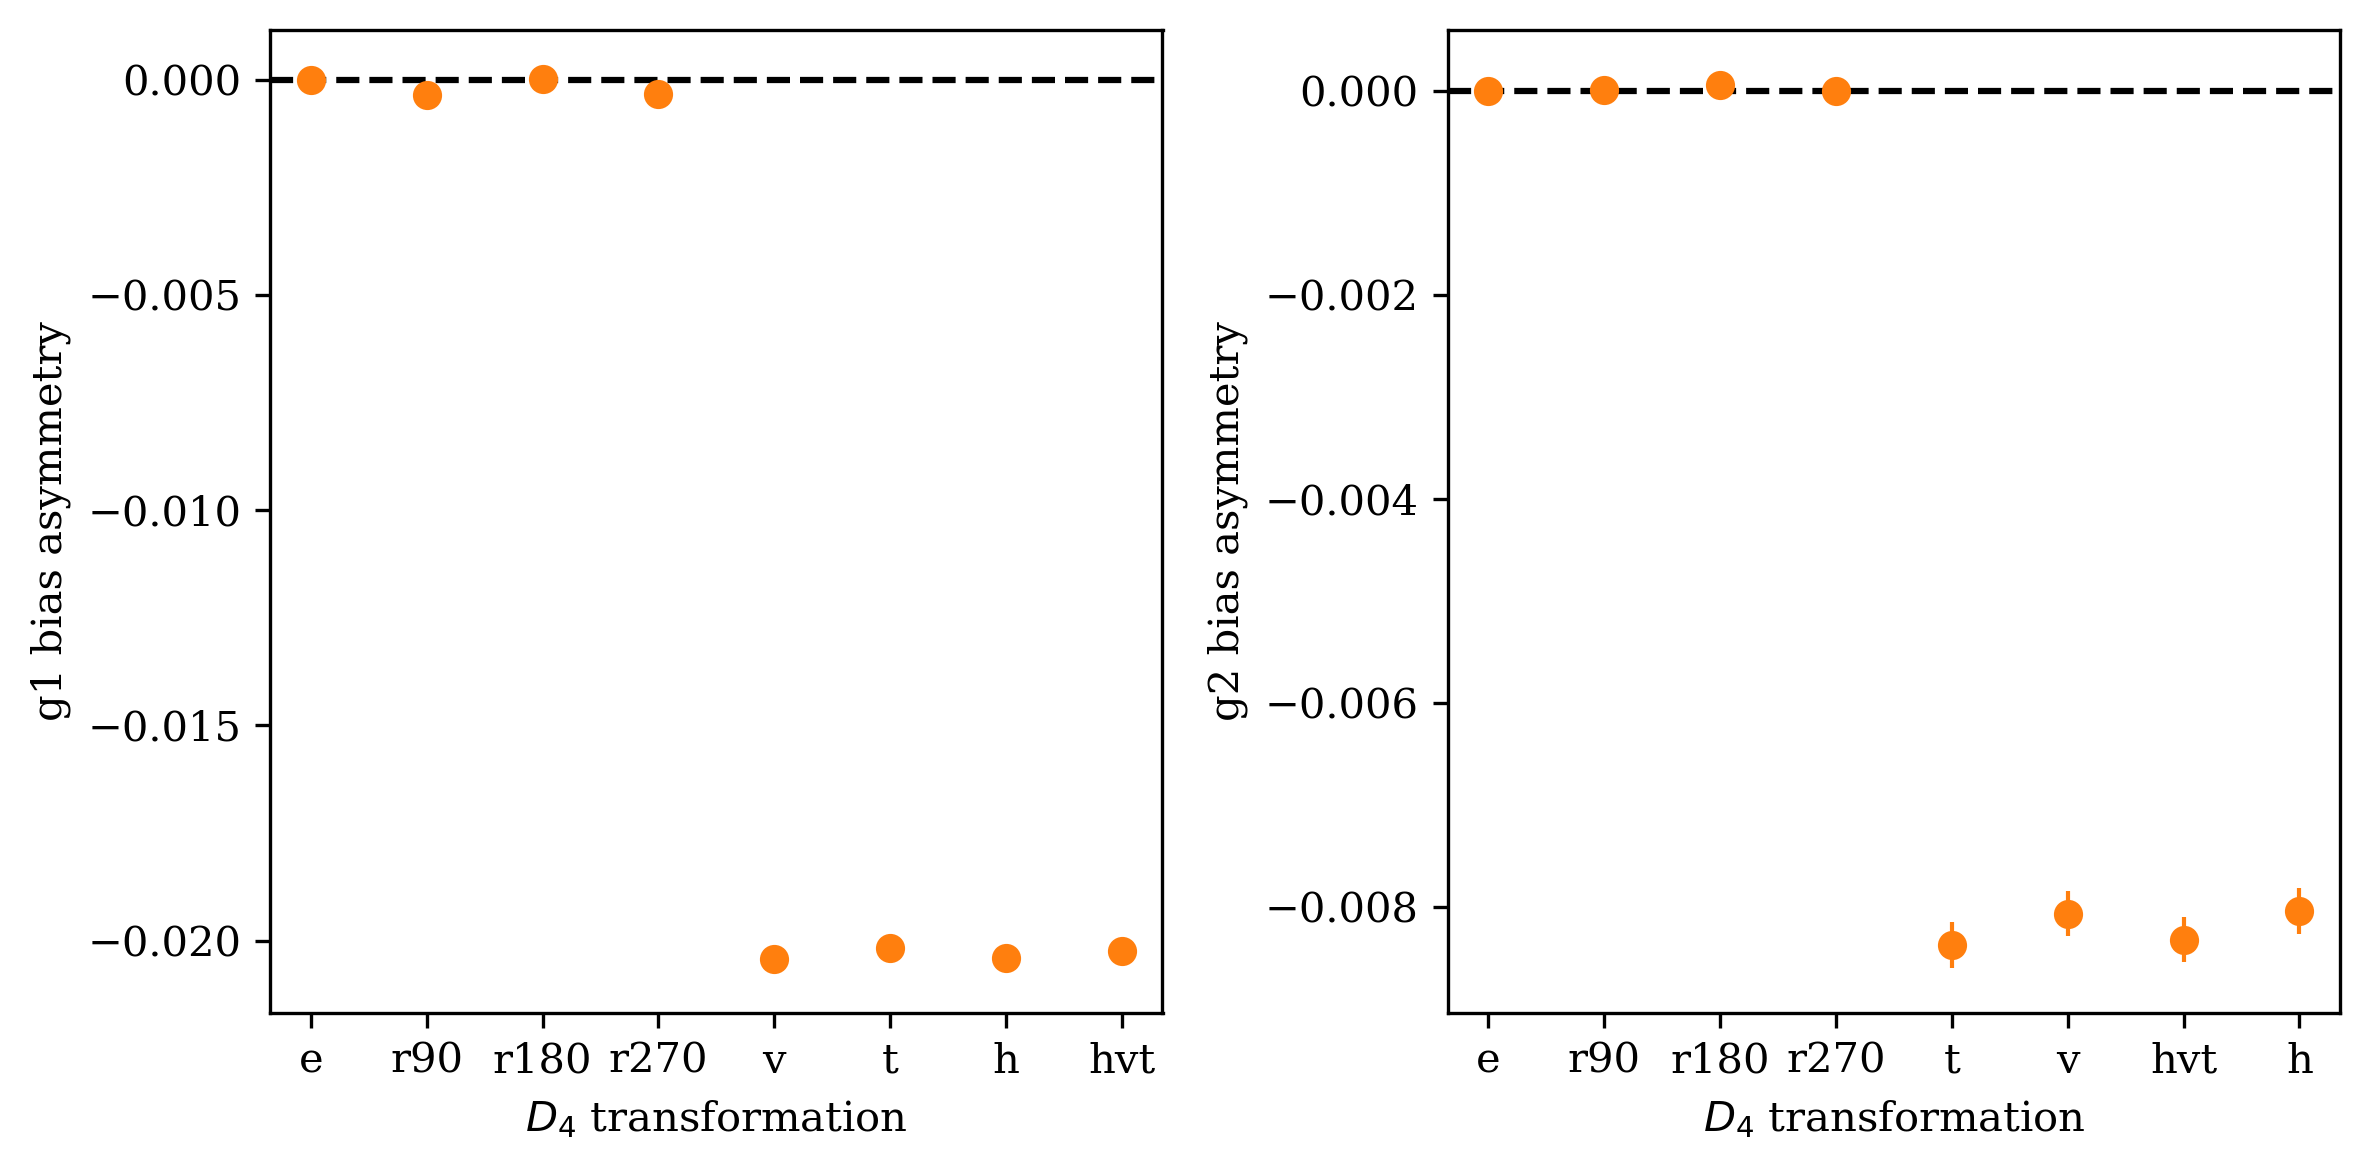

In [41]:
x = np.arange(0, 8)
axs = plt.figure(figsize=(8, 4)).subplots(1, 2)
identity = g_bias[0]
for i, ax in enumerate(axs.ravel()):
    order = [0, 1, 2, 3, 4, 5, 6, 7] if i == 0 else [0, 1, 2, 3, 5, 4, 7, 6]
    ticklabel = [d4_trans[order[i]] for i in range(8)]
    flip_identity = (1)**x*identity[i]
    ax.errorbar(x, g_bias[order, i]-flip_identity, g_std[order, i], linestyle='', elinewidth=1, marker='o', color='C1')
    ax.axhline(0, linestyle='--', color='black')
    ax.set_xticks(x, labels=ticklabel)
    # ax.set_ylim(-0.005, 0.005)
    ax.set_xlabel(r'$D_4$ transformation')
    ax.set_ylabel(f'g{i+1} bias asymmetry')

plt.tight_layout()
plt.savefig(join(fig_dir, stem, f'D4_summary_diff_g_{nsamps}.png'), dpi=300)
plt.show()


In [42]:
avg_bias_all = np.mean(diffs, axis=0)

In [43]:
avg_bias_diff = avg_bias_all.copy()
identity = avg_bias_diff[0]
avg_bias_diff -= identity
# avg_bias_diff[[1, 3, 5, 7], 0] += 2*identity[0]
# avg_bias_diff[[1, 3, 4, 6], 1] += 2*identity[1]

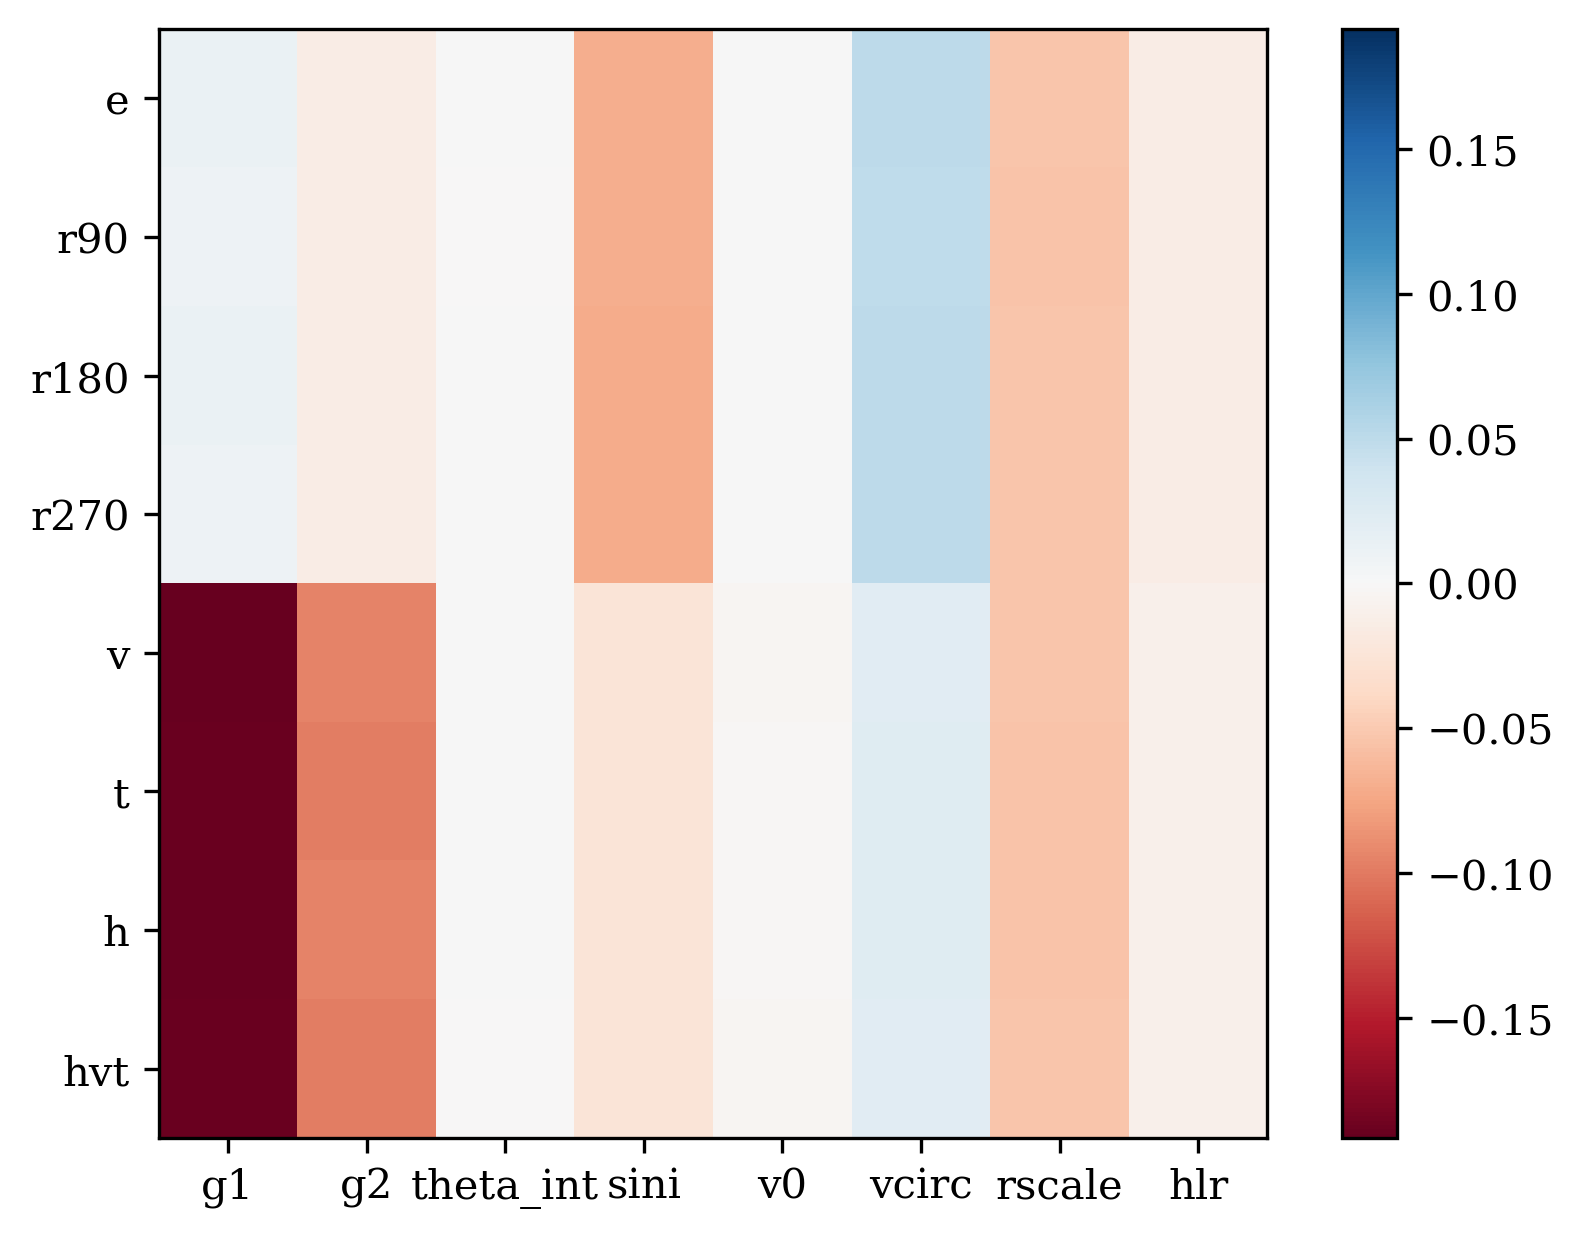

In [44]:
plt.imshow(avg_bias_all, cmap='RdBu', norm=colors.CenteredNorm())
plt.xticks(x, labels=config.train['feature_names'])
plt.yticks(x, labels=d4_trans)
plt.colorbar()
plt.savefig(join(fig_dir, stem, f'D4_diff_all_params_{nsamps}.png'), dpi=300)
plt.show()


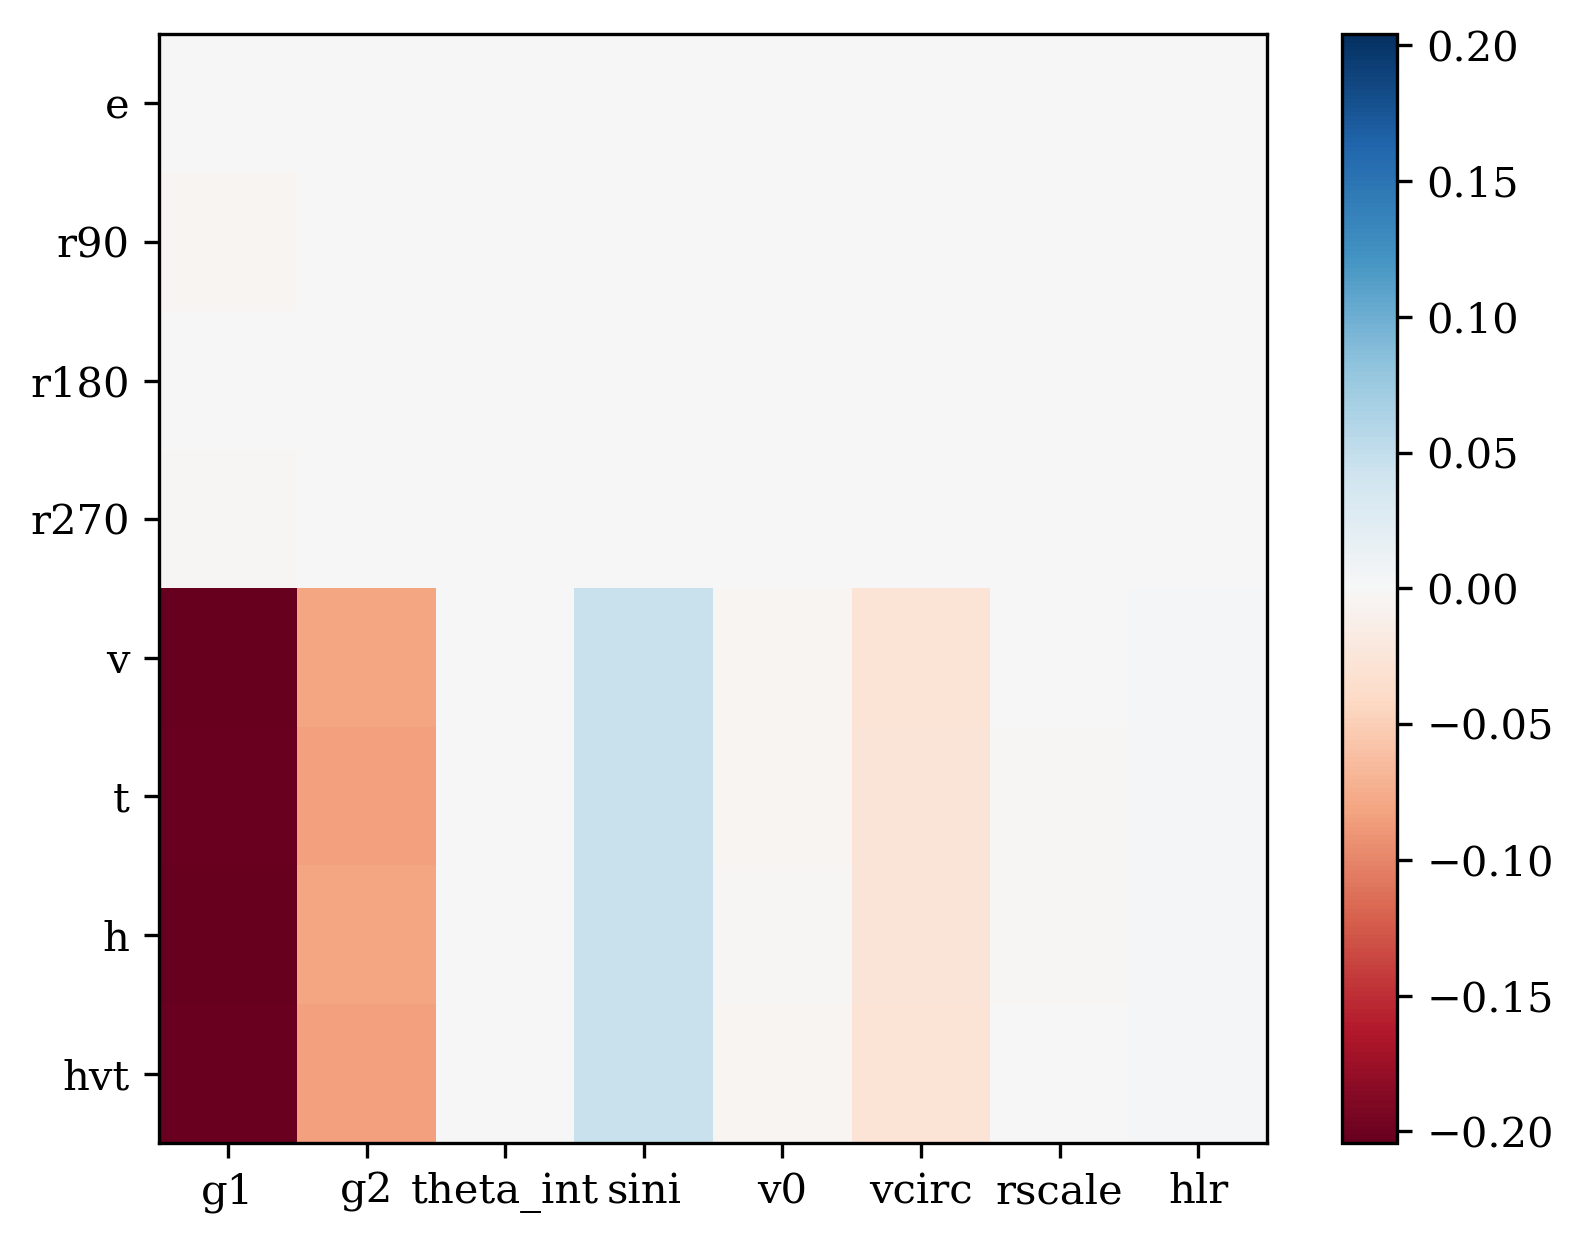

: 

In [ ]:
plt.imshow(avg_bias_diff, cmap='RdBu', norm=colors.CenteredNorm())
plt.xticks(x, labels=config.train['feature_names'])
plt.yticks(x, labels=d4_trans)
plt.colorbar()
plt.savefig(join(fig_dir, stem, f'D4_diff_all_params_diff_{nsamps}.png'), dpi=300)
plt.show()

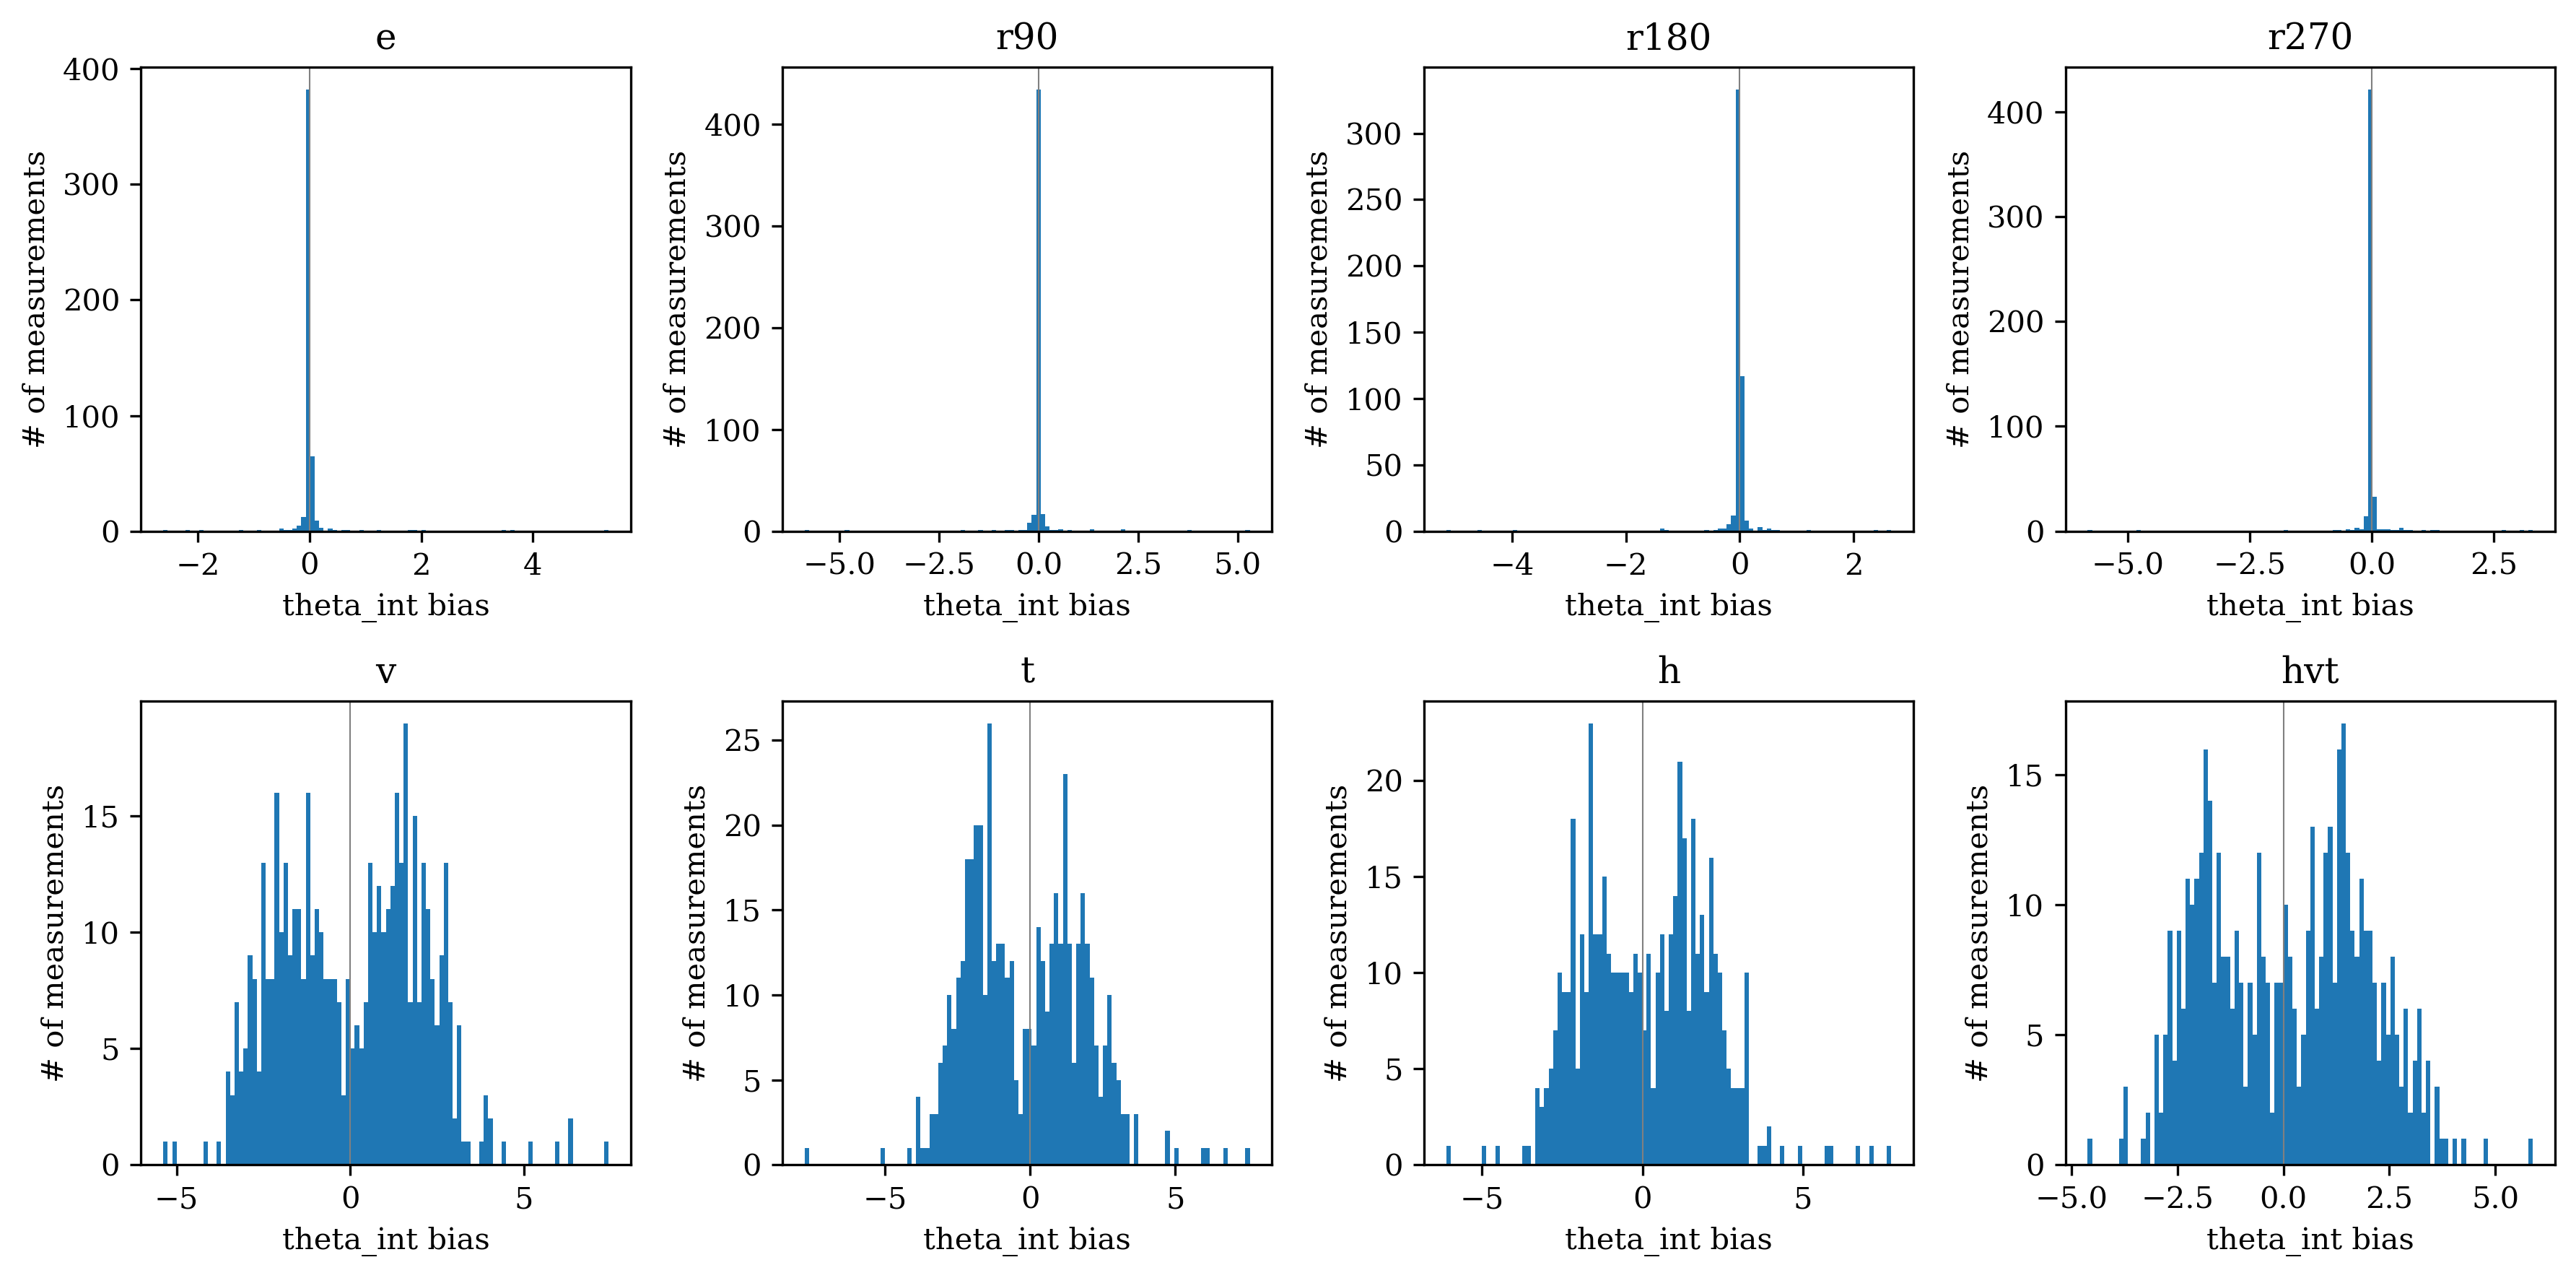

In [24]:
axs = plt.figure(figsize=(12, 6)).subplots(2, 4)
for i, ax in enumerate(axs.ravel()):
    ax.axvline(0, color='gray', lw=0.5)
    ax.hist(diffs[:, i, 2] * np.pi, bins=100)
    ax.set_xlabel('theta_int bias')
    ax.set_ylabel('# of measurements')
    ax.set_title(d4_trans[i])

plt.tight_layout()
plt.savefig(join(fig_dir, stem, f'D4_theta_analysis.png'), dpi=300)
plt.show()


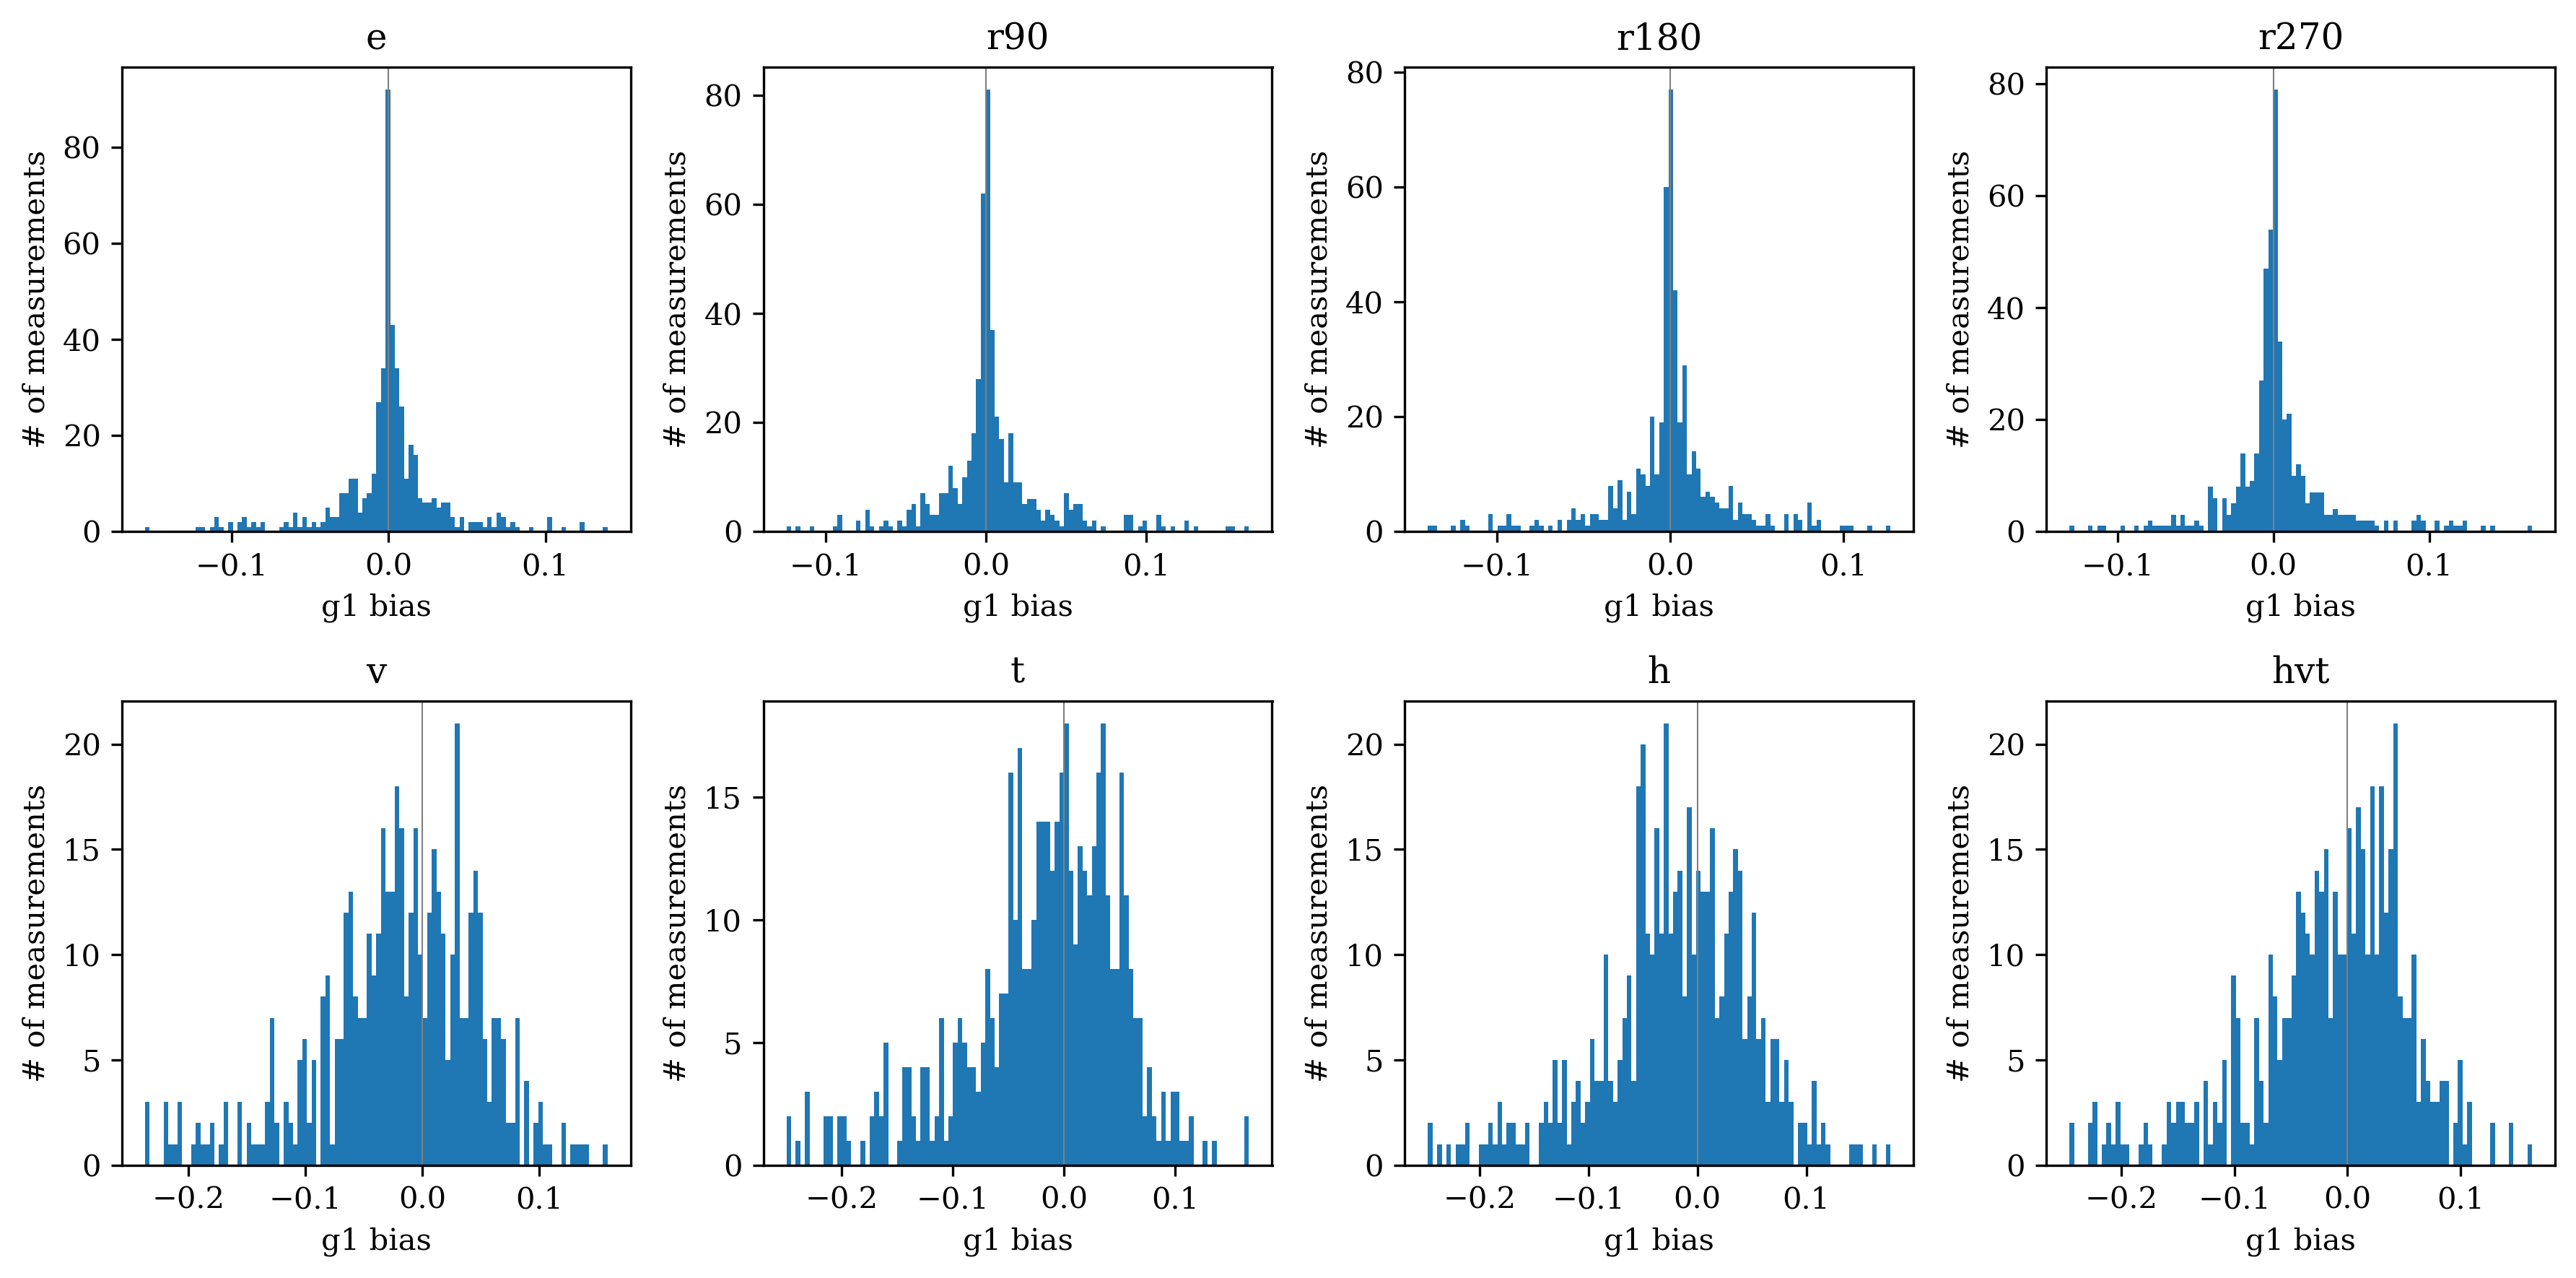

In [25]:
axs = plt.figure(figsize=(12, 6)).subplots(2, 4)
for i, ax in enumerate(axs.ravel()):
    ax.axvline(0, color='gray', lw=0.5)
    ax.hist(diffs[:, i, 0] * 0.1, bins=100)
    ax.set_xlabel('g1 bias')
    ax.set_ylabel('# of measurements')
    ax.set_title(d4_trans[i])

plt.tight_layout()
plt.savefig(join(fig_dir, stem, f'D4_g1_analysis.png'), dpi=300)
plt.show()


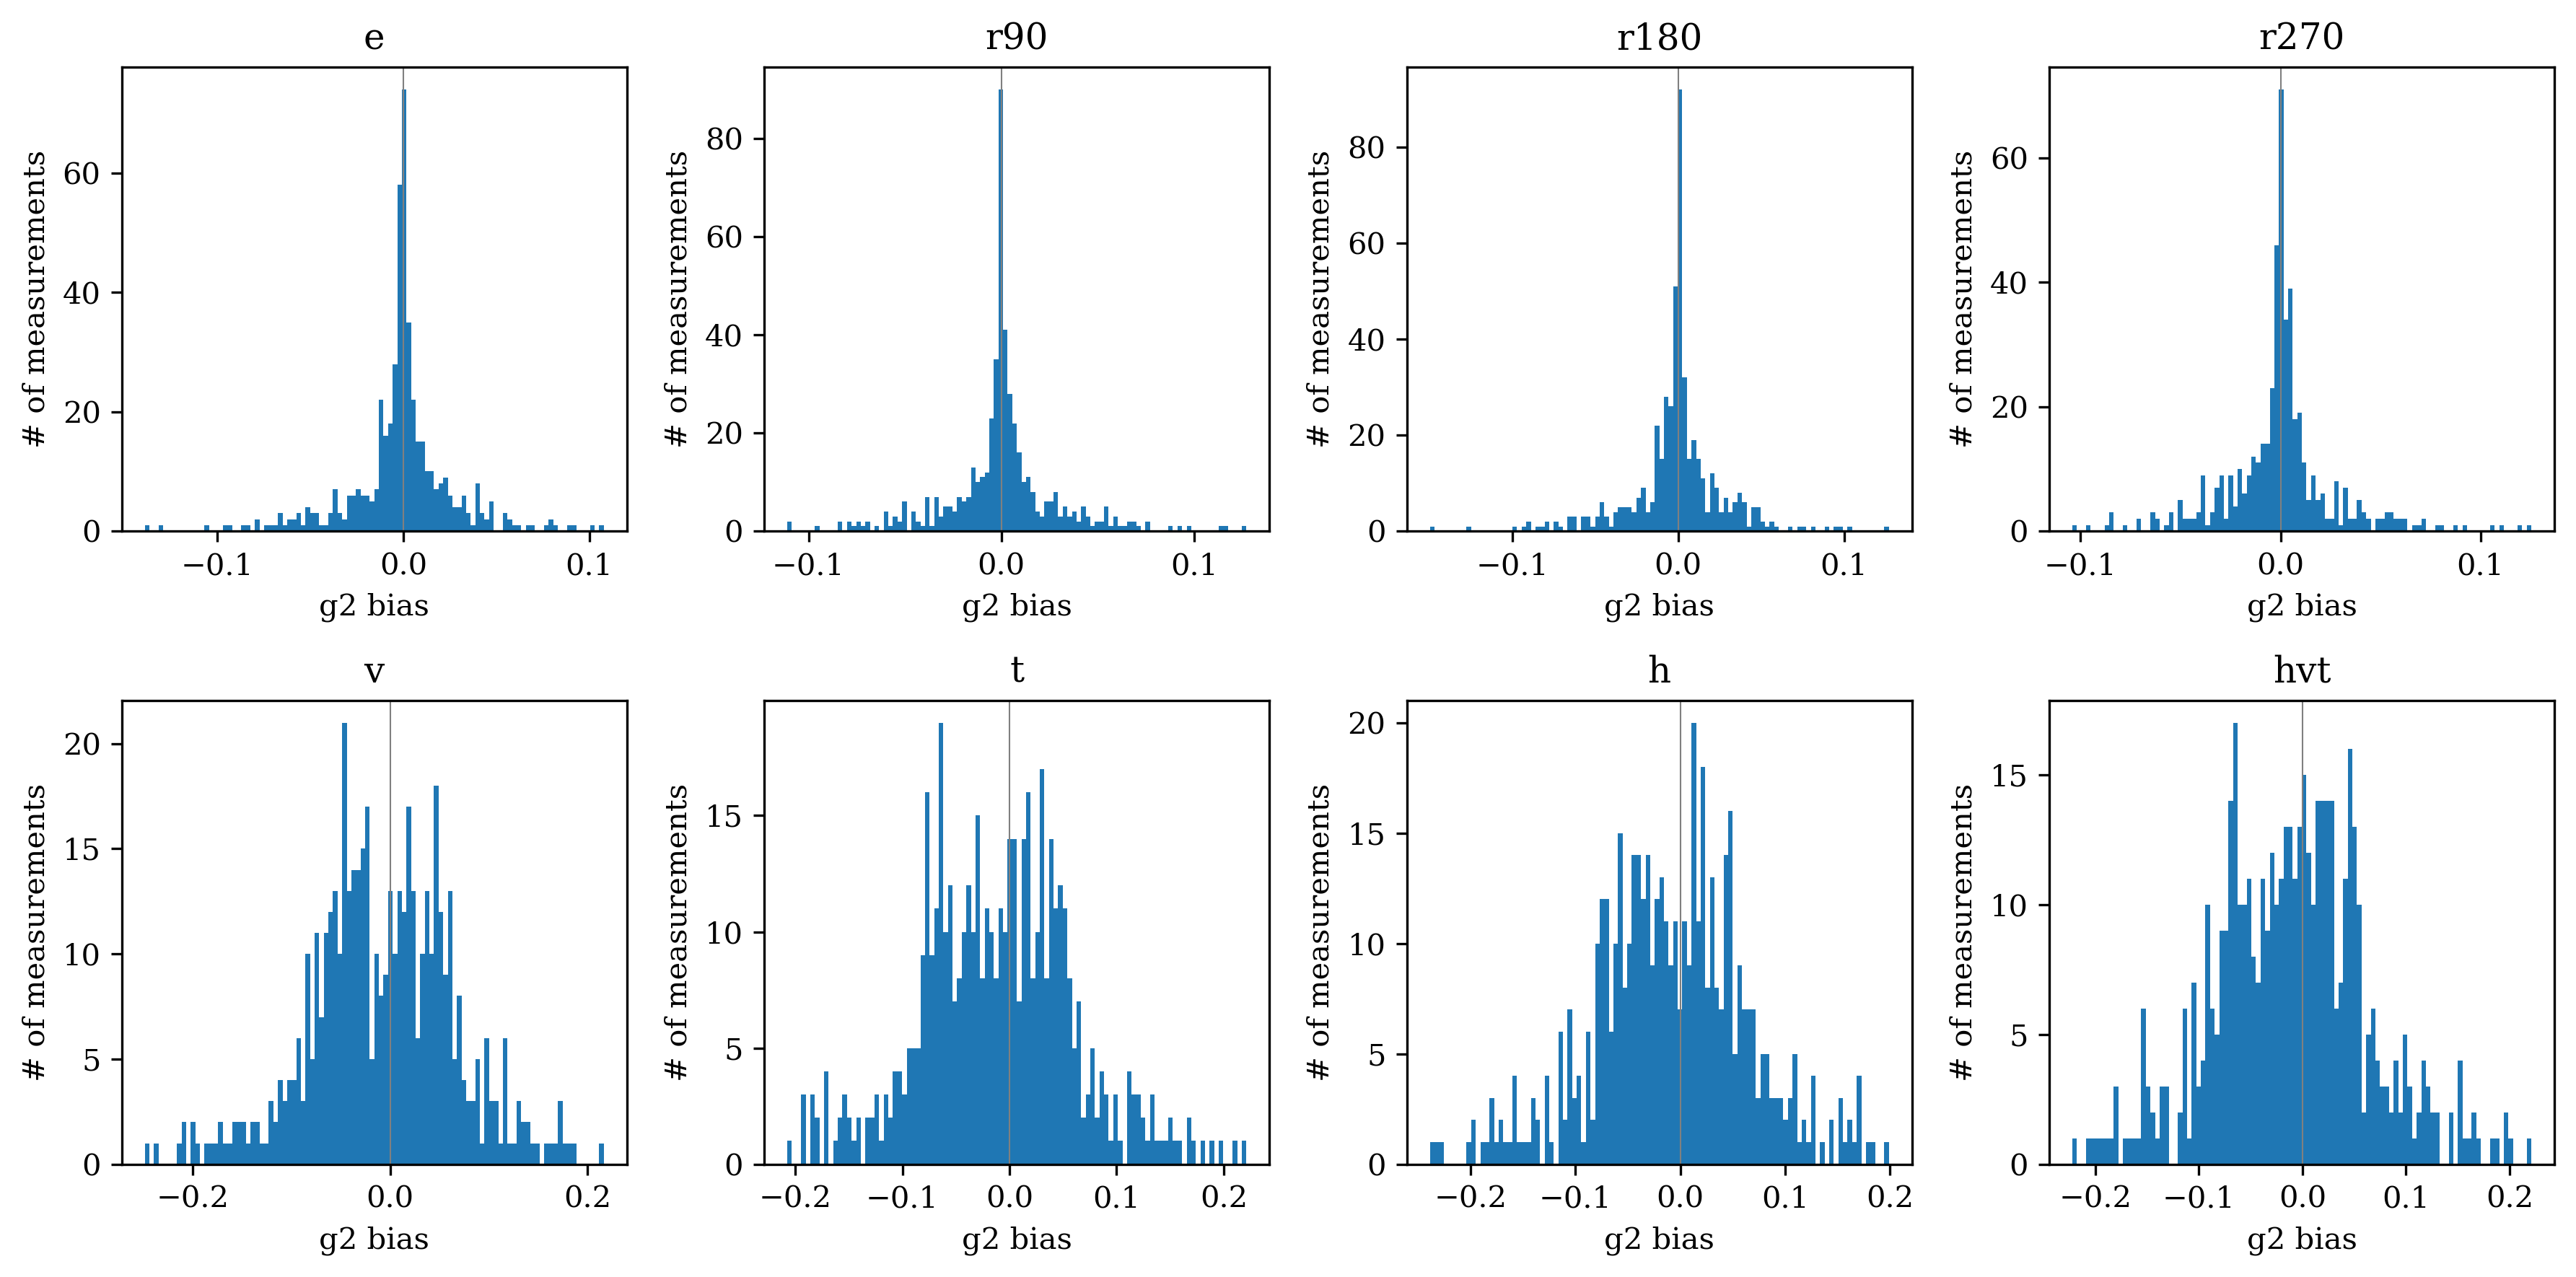

In [26]:
axs = plt.figure(figsize=(12, 6)).subplots(2, 4)
for i, ax in enumerate(axs.ravel()):
    ax.axvline(0, color='gray', lw=0.5)
    ax.hist(diffs[:, i, 1] * 0.1, bins=100)
    ax.set_xlabel('g2 bias')
    ax.set_ylabel('# of measurements')
    ax.set_title(d4_trans[i])

plt.tight_layout()
plt.savefig(join(fig_dir, stem, f'D4_g2_analysis.png'), dpi=300)
plt.show()


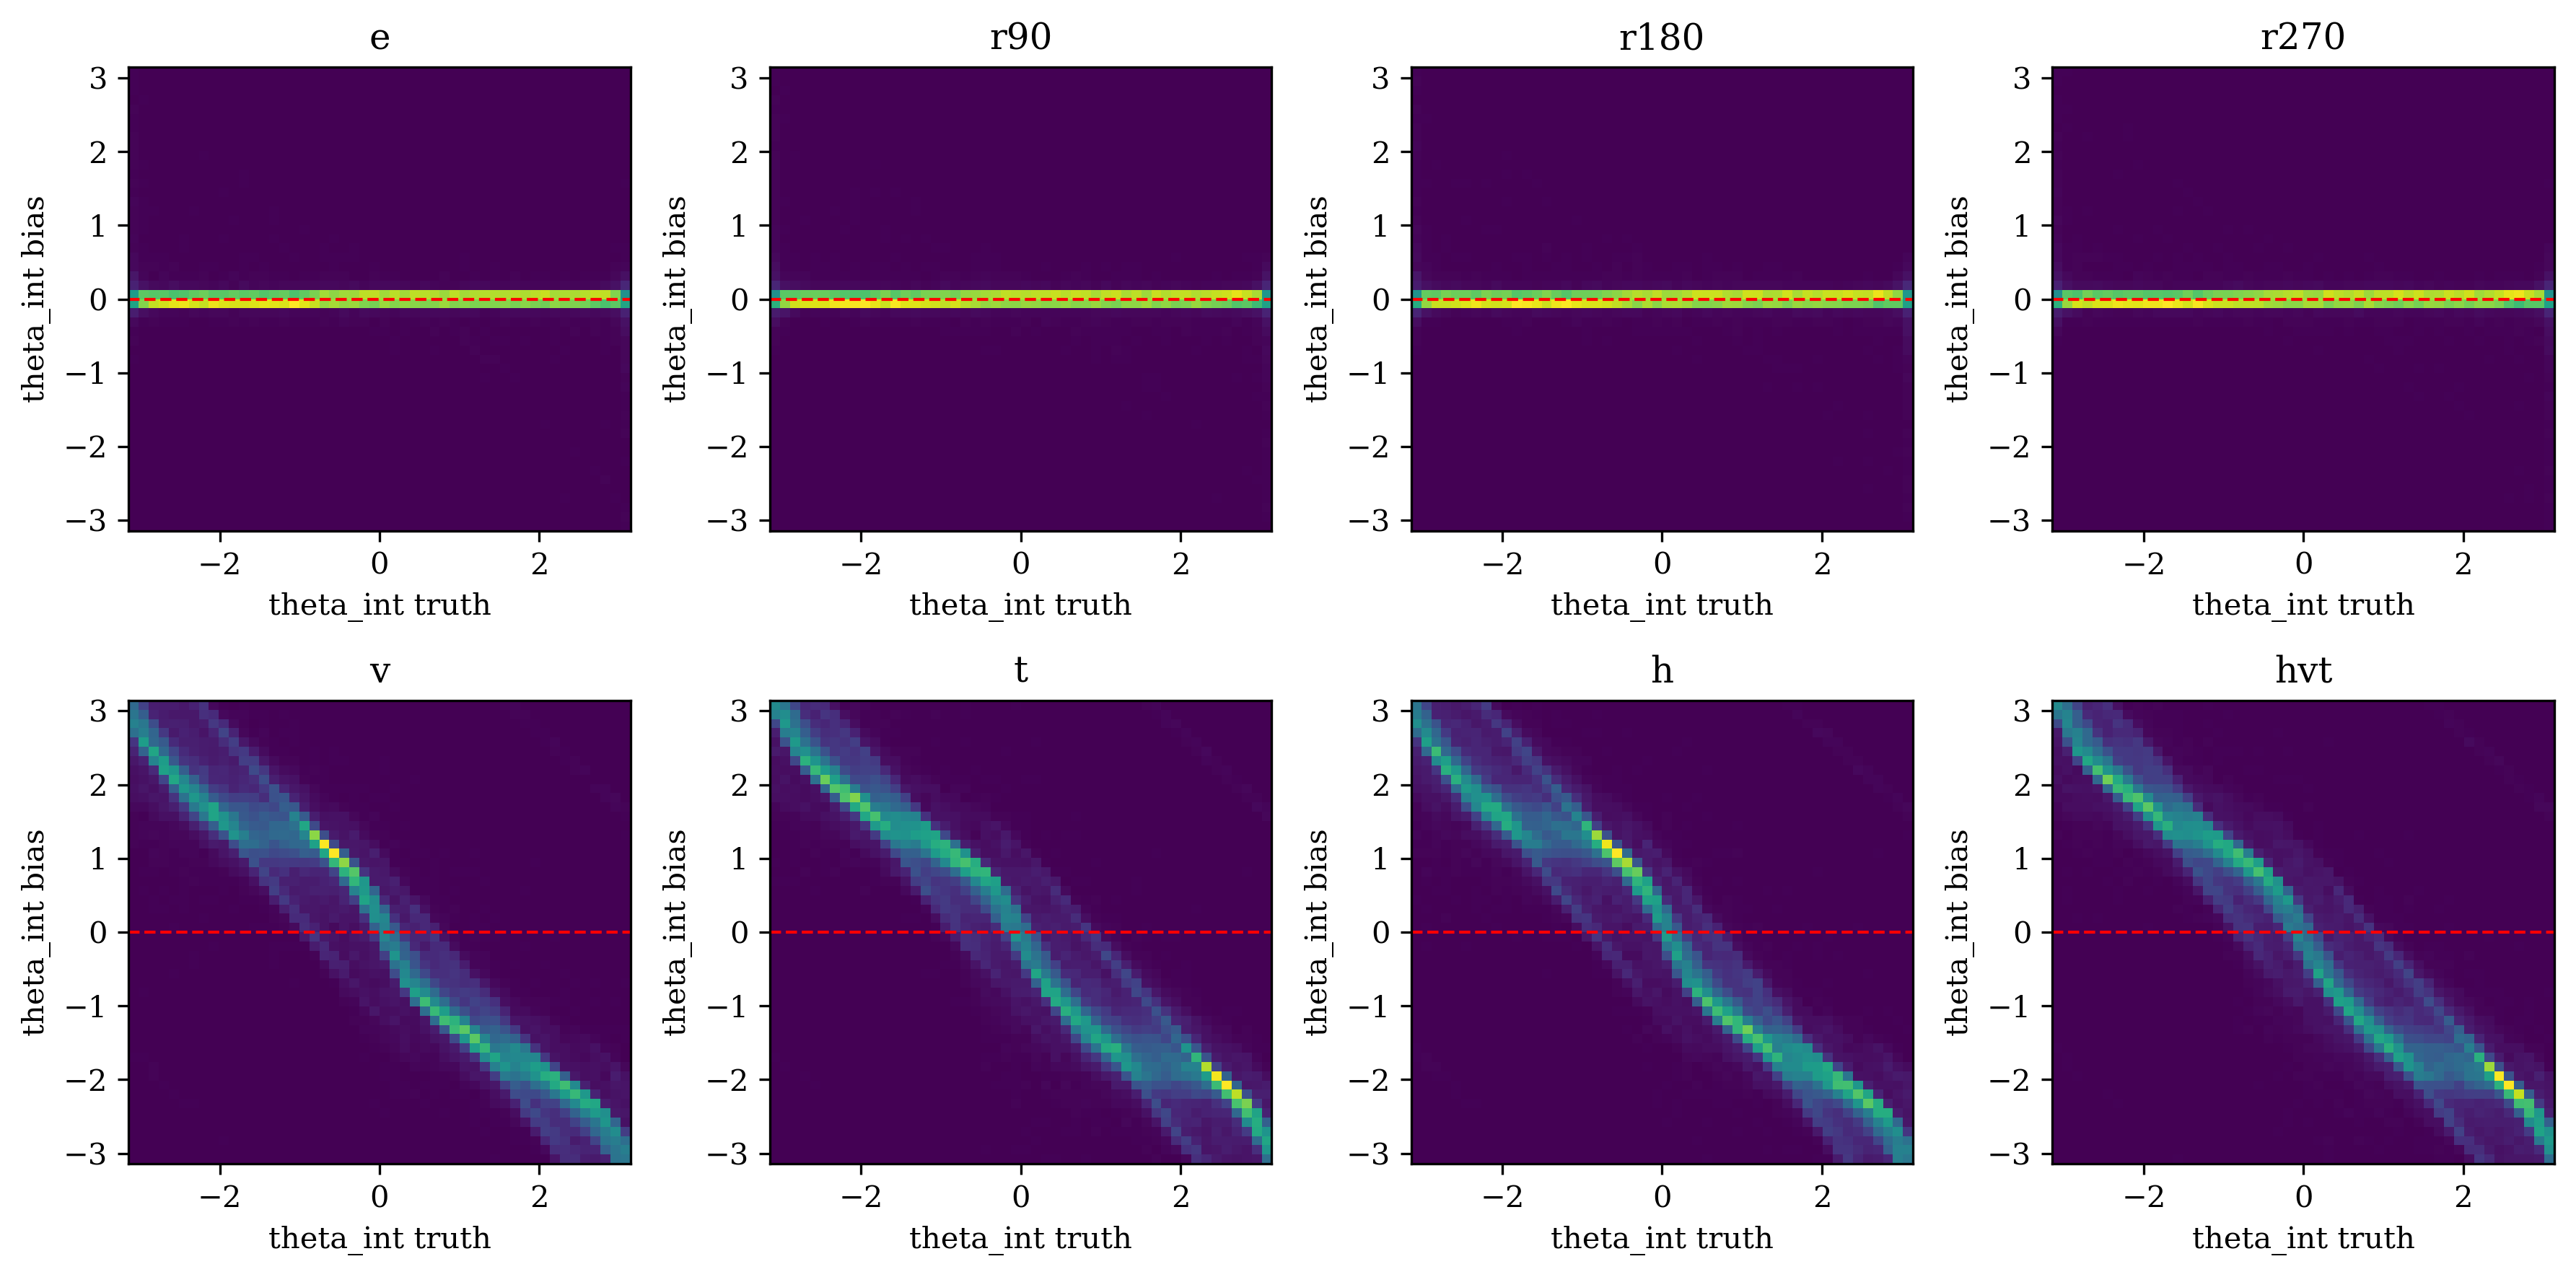

In [19]:
axs = plt.figure(figsize=(12, 6)).subplots(2, 4)
for i, ax in enumerate(axs.ravel()):
    ax.axhline(0, color='red', linestyle='--',lw=1)
    ax.hist2d(truths[:, i, 2] * np.pi, diffs[:, i, 2] * np.pi, range=[[-np.pi, np.pi], [-np.pi, np.pi]], bins=50)
    ax.set_xlabel('theta_int truth')
    ax.set_ylabel('theta_int bias')
    ax.set_title(d4_trans[i])

plt.tight_layout()
plt.savefig(join(fig_dir, stem, f'D4_theta_analysis_2d.png'), dpi=300)
plt.show()

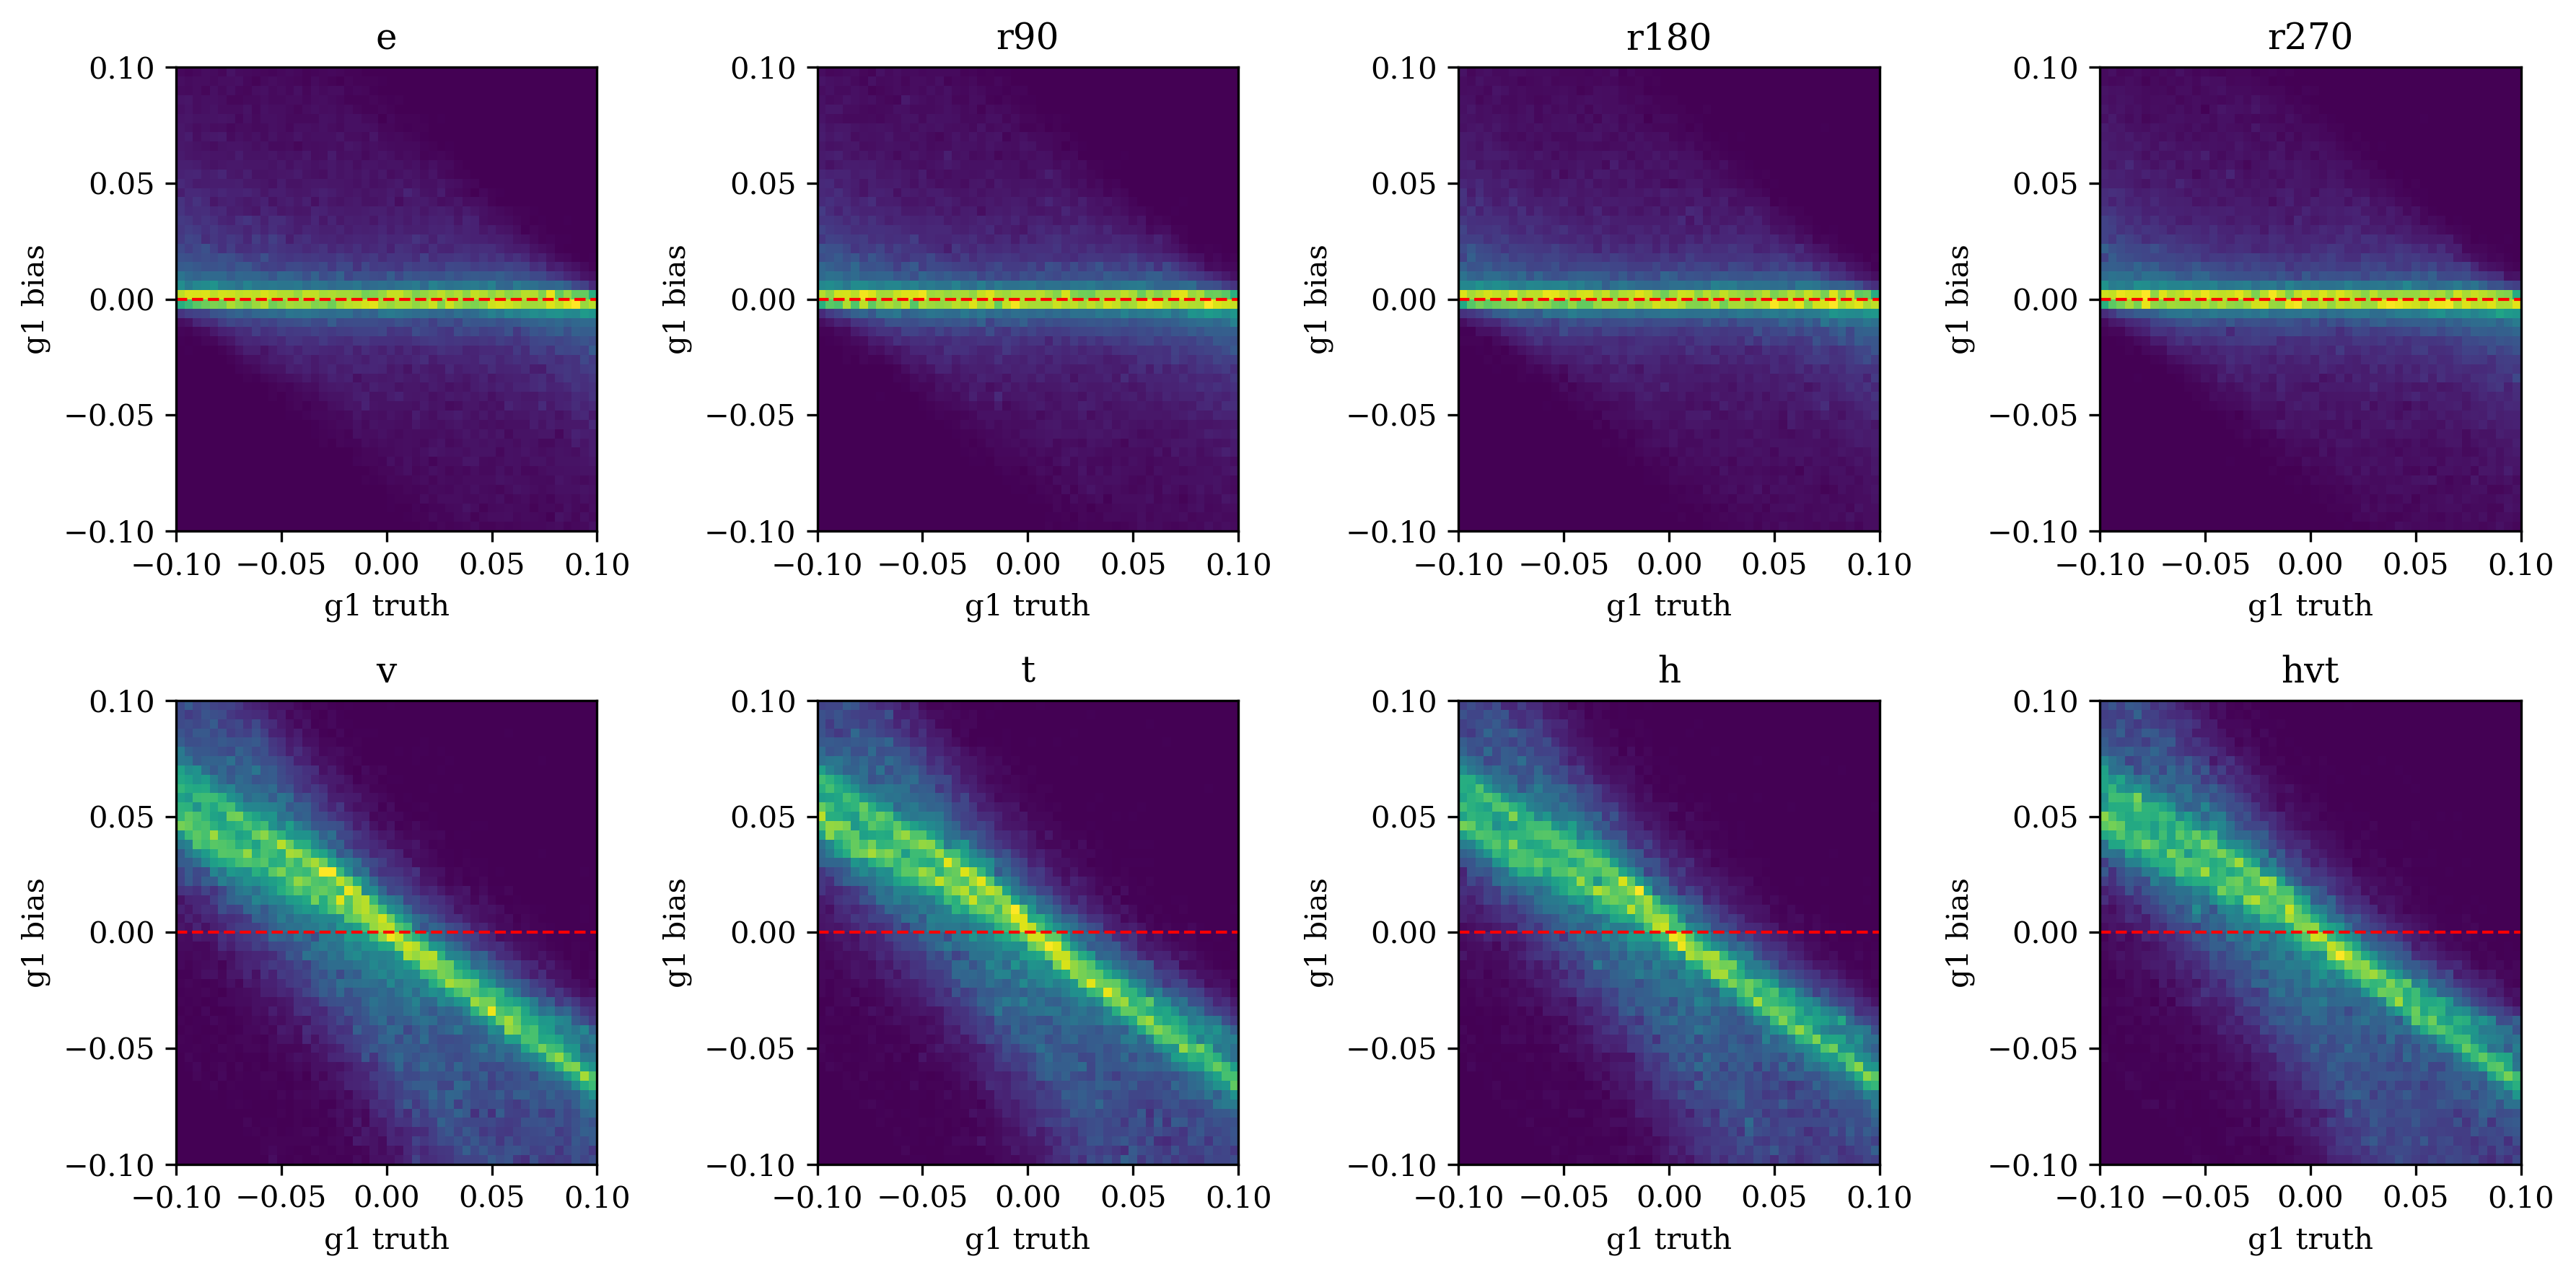

In [20]:
axs = plt.figure(figsize=(12, 6)).subplots(2, 4)
for i, ax in enumerate(axs.ravel()):
    ax.axhline(0, color='red', linestyle='--',lw=1)
    ax.hist2d(truths[:, i, 0] * 0.1, diffs[:, i, 0] * 0.1, range=[[-0.1, 0.1], [-0.1, 0.1]], bins=50)
    ax.set_xlabel('g1 truth')
    ax.set_ylabel('g1 bias')
    ax.set_title(d4_trans[i])

plt.tight_layout()
plt.savefig(join(fig_dir, stem, f'D4_g1_analysis_2d.png'), dpi=300)
plt.show()

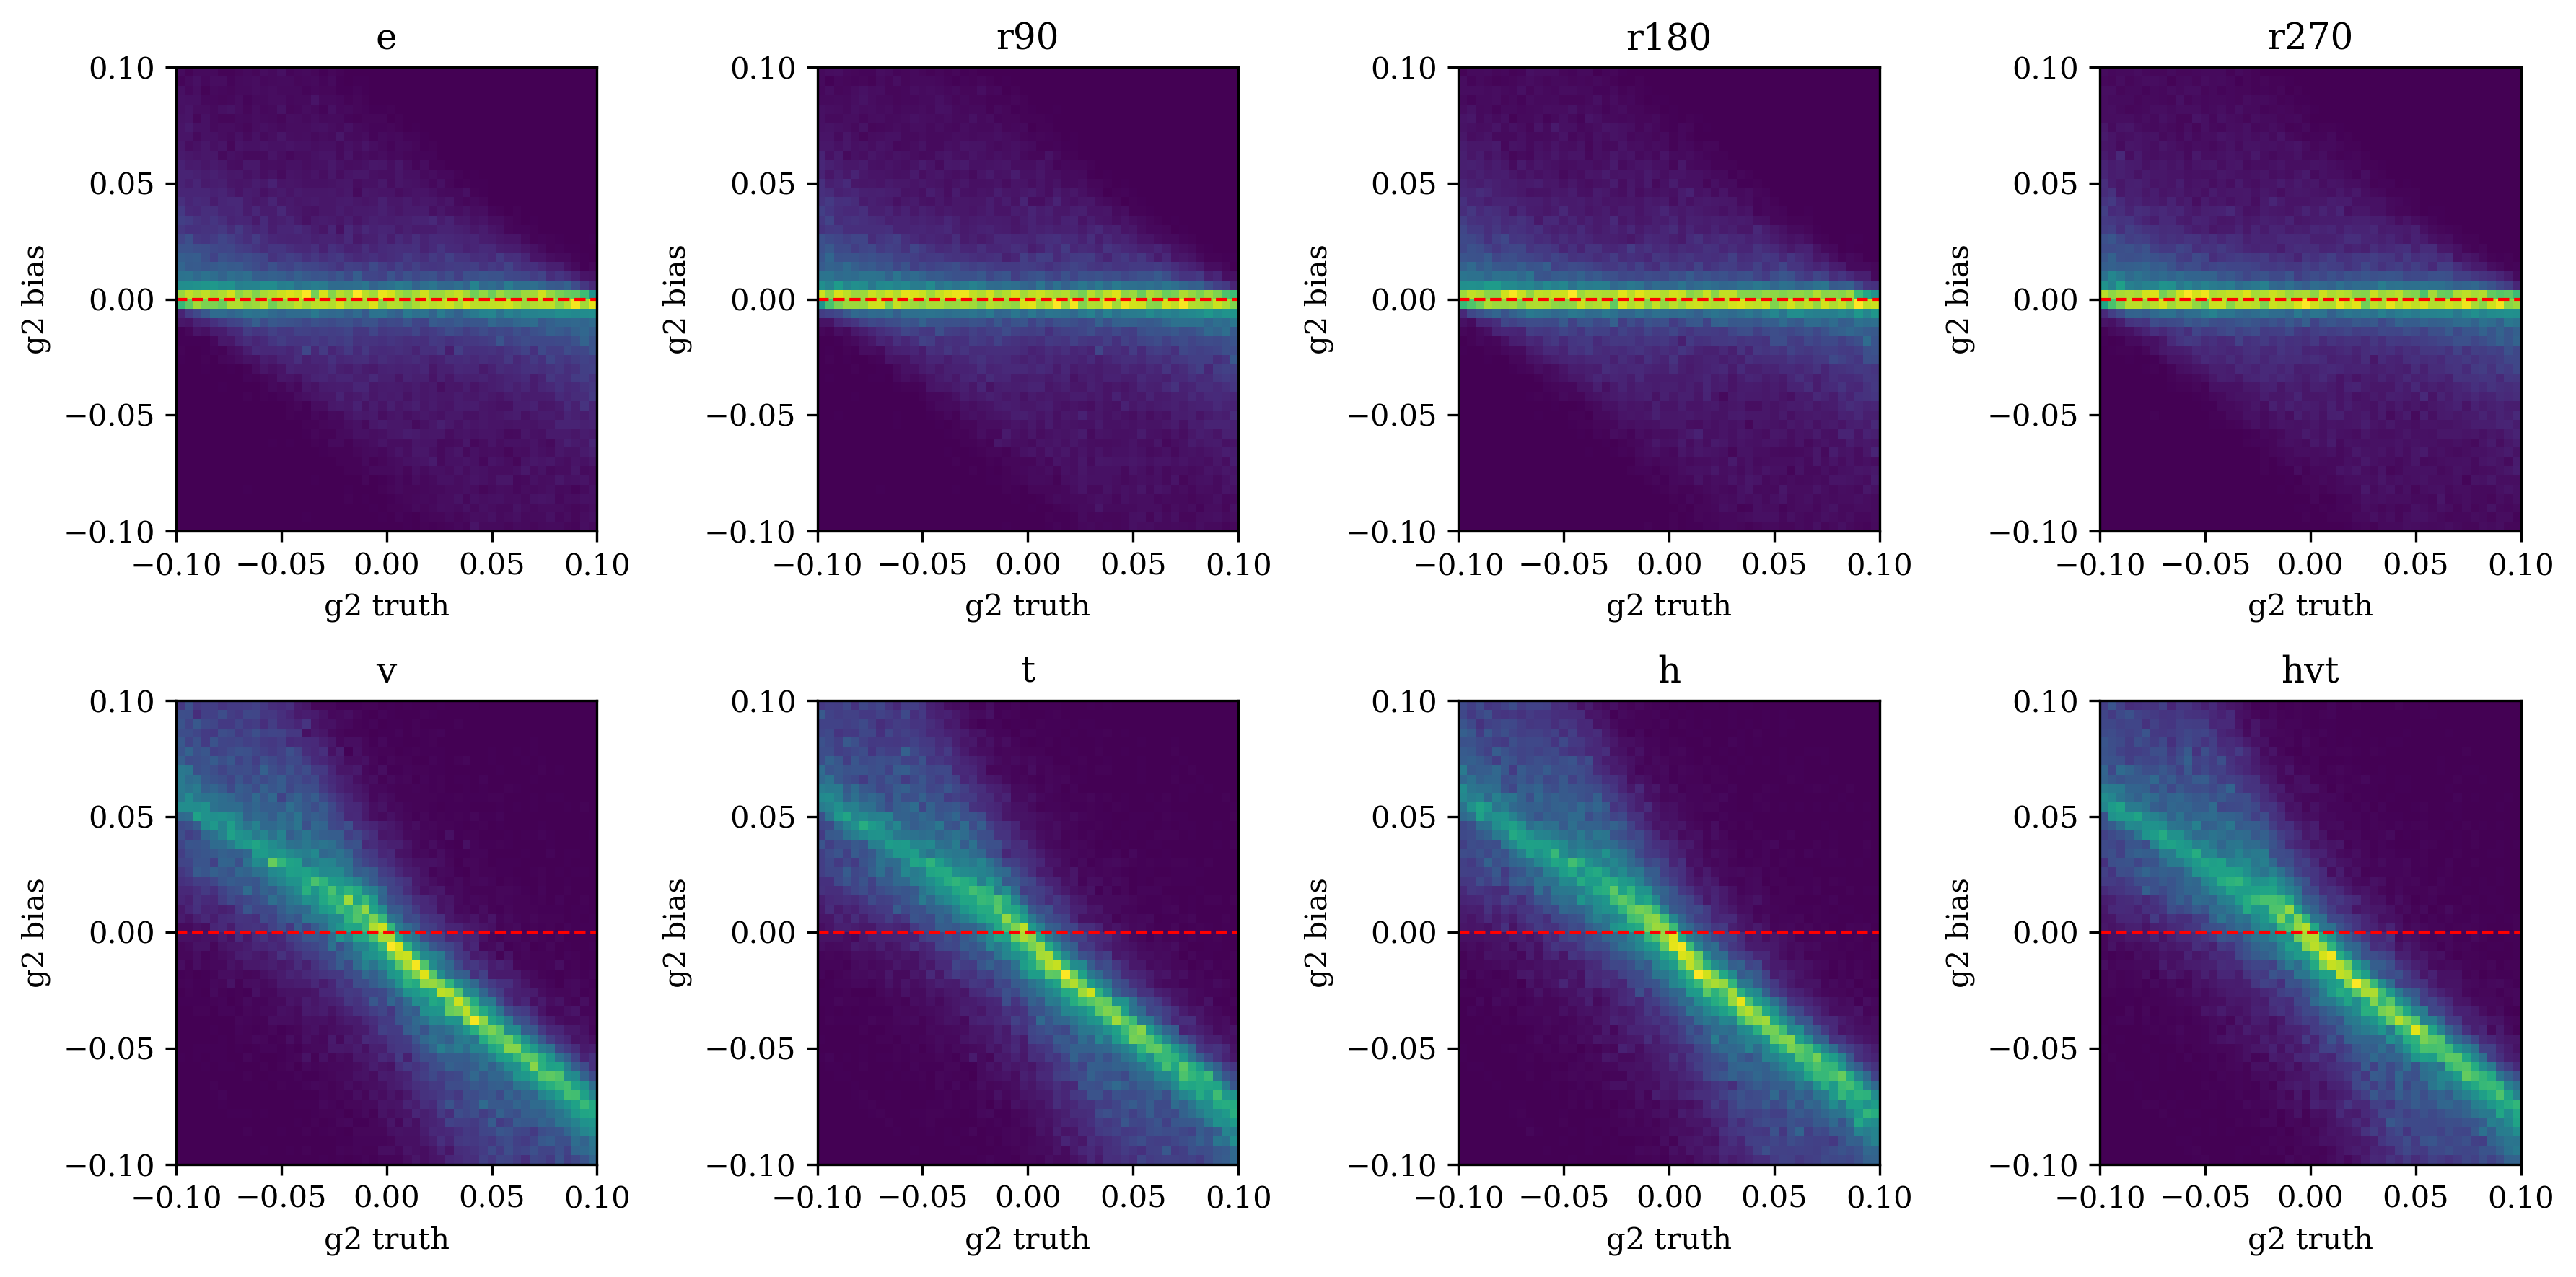

In [21]:
axs = plt.figure(figsize=(12, 6)).subplots(2, 4)
for i, ax in enumerate(axs.ravel()):
    ax.axhline(0, color='red', linestyle='--',lw=1)
    ax.hist2d(truths[:, i, 1] * 0.1, diffs[:, i, 1] * 0.1, range=[[-0.1, 0.1], [-0.1, 0.1]], bins=50)
    ax.set_xlabel('g2 truth')
    ax.set_ylabel('g2 bias')
    ax.set_title(d4_trans[i])

plt.tight_layout()
plt.savefig(join(fig_dir, stem, f'D4_g2_analysis_2d.png'), dpi=300)
plt.show()